# Прогноз оттока клиентов (Customer Churn Prediction)

Ноутбук решает задачу **бинарной классификации**: по данным телеком-компании предсказать, уйдёт ли клиент (`Churn = Yes/No`). Датасет — классический *Telco Customer Churn* (Kaggle, ~7 тыс. клиентов): демография, подключённые услуги, тип контракта, платежи.

**Почему эта задача важна для бизнеса.** Удержать существующего клиента в разы дешевле, чем привлечь нового. Если модель заранее указывает клиентов с высоким риском ухода, отдел удержания может точечно предложить им скидку/бонус — вместо того чтобы «поливать» скидками всех подряд.

**Логика проекта (почему разделы идут именно в таком порядке):** сначала смотрим на данные и чистим их (нельзя моделировать «грязные» данные) → изучаем связи признаков с оттоком (EDA подсказывает, какие признаки создавать) → создаём новые признаки → кодируем категории в числа (модели понимают только числа) → обучаем модели от простой к сложной и честно сравниваем их на отложенной выборке.

---

## Оглавление

1. **Импорт библиотек** — инструменты проекта и зачем каждый нужен; версии библиотек для воспроизводимости
2. **Загрузка данных** — читаем CSV, первый взгляд на таблицу
3. **Проверка пропусков** — обычные `NaN` и «скрытые» пропуски-пробелы; 3.1 — визуальная карта пропусков
4. **Доля оттока** — оцениваем дисбаланс классов (это влияет на выбор метрик и настроек моделей)
5. **Предобработка** — удаляем ID, чиним `TotalCharges`, убираем клиентов с `tenure == 0`
6. **EDA (разведочный анализ)** — 6.1 churn rate по категориям; 6.1b ранжирование признаков через χ² / Cramér's V; 6.2 агрегаты и «опасные комбинации»; 6.3 распределения числовых признаков; 6.4 scatter plot `tenure × MonthlyCharges`
7. **Feature Engineering** — группировки, флаги, `charges_diff`; 7.1 признаки-взаимодействия
8. **Кодирование категорий** — 8.1 бинарные → 0/1; 8.2 one-hot (+ копия сырых категорий для CatBoost)
9. **Финальная проверка перед моделированием** — 9.1 полная корреляционная матрица и мультиколлинеарность; 9.2 удаляем признаки-дубли и проверяем, что качество не упало
10. **Train/test split** — стратифицированное разбиение 80/20; 10.1 вспомогательная функция оценки
11. **Baseline: LogisticRegression** — 11.1 метрики на тесте; 11.2 confusion matrix; 11.3 DummyClassifier (нижняя граница); 11.4 кросс-валидация; 11.5 подбор гиперпараметров (GridSearchCV)
12. **CatBoost + Optuna** — байесовский подбор гиперпараметров; 12.1 нативные категориальные признаки (`cat_features`); 12.2 отдельный Optuna-тюнинг нативной версии
13. **LightGBM + Optuna** — второй бустинг для сравнения + графики хода оптимизации; 13.1 нативные категориальные признаки
14. **Сравнение моделей** — единый сбор предсказаний, сводные таблицы ROC-AUC и Recall; 14.1 бутстрэп-доверительные интервалы на AUC
15. **ROC- и Precision-Recall-кривые** — 15.1 ROC; 15.2 PR (честнее при дисбалансе)
16. **Важность признаков** — какие признаки двигают предсказание лучшей модели; 16.1 SHAP: направление и величина вкладов, разложение прогнозов клиентов
17. **Выбор порога классификации** — 17.1 перебор порогов по out-of-fold предсказаниям; 17.2 применение к тесту один раз
18. **Калибровка вероятностей** — reliability-кривая, isotonic-калибровка «до/после»
19. **Сохранение артефактов** — модель, калиброванная версия, порог + метаданные (JSON)

---

**Как читать ноутбук:** перед каждым блоком кода стоит пояснение *что делаем → зачем именно это → как оно работает под капотом*; после ключевых графиков — блок «Что видно на графике» с выводами.


## 1. Импорт библиотек

Подключаем четыре базовые библиотеки — «рабочий стол» любого DS-проекта:

- **`numpy` (`np`)** — быстрые вычисления над массивами чисел. Здесь используем для `np.nan` (стандартное обозначение пропуска), `np.triu` (верхний треугольник корреляционной матрицы в 9.1) и `np.maximum.accumulate` (кривая «лучший результат Optuna на данный момент» в разделе 13). Работает быстро, потому что операции выполняются векторно на уровне C, а не в цикле Python.
- **`pandas` (`pd`)** — таблицы данных (`DataFrame`). Вся загрузка, чистка, группировки (`groupby`), сводные таблицы (`crosstab`) и кодирование (`get_dummies`) делаются через pandas.
- **`matplotlib.pyplot` (`plt`)** — низкоуровневая библиотека графиков: управляем размером фигур, подписями осей, сетками субплотов.
- **`seaborn` (`sns`)** — надстройка над matplotlib для статистических графиков: одной строкой рисует гистограммы с разбивкой по классу (`hue`), boxplot'ы, heatmap'ы. Под капотом всё равно matplotlib, поэтому их можно свободно смешивать (что мы и делаем).

Библиотеки моделей (`sklearn`, `catboost`, `lightgbm`, `optuna`, `scipy`) импортируем позже — в тех разделах, где они впервые нужны: так по импорту сразу видно, какой раздел от чего зависит.


In [205]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%pip install optuna catboost scikit-learn

Note: you may need to restart the kernel to use updated packages.


**Фиксируем версии библиотек.** Ноутбук должен быть воспроизводим: результаты Optuna (даже с `seed=42`) могут отличаться между версиями самой Optuna, sklearn и бустингов — меняются детали сэмплера, дефолтные параметры моделей, генераторы случайности. Печать версий в начале — дешёвая страховка: если через полгода цифры «поплыли», первым делом сверяем этот вывод со старым.

In [206]:
import sys as _sys
import sklearn, scipy, matplotlib, catboost, lightgbm, optuna

## 2. Загрузка данных

`pd.read_csv` читает CSV-файл в `DataFrame` — таблицу, где строка = один клиент, столбец = один признак.

Сразу после загрузки смотрим `df.shape` — пару `(число строк, число столбцов)`. Это первая «санитарная» проверка: убеждаемся, что файл прочитался целиком (~7043 клиента × 21 столбец) и что структура соответствует ожиданиям, прежде чем что-либо считать.

Дальше стандартный минимальный осмотр нового датасета — четыре команды, каждая отвечает на свой вопрос:

| Команда | На какой вопрос отвечает |
|---|---|
| `df.head()` | Как физически выглядят данные? (первые 5 строк) |
| `df.info()` | Какие типы у столбцов и где есть пустоты? |
| `df.describe()` | Каковы диапазоны и средние числовых признаков? Нет ли аномалий (отрицательный платёж, tenure = 1000)? |
| `df.describe(include='object')` | Сколько уникальных категорий в текстовых столбцах и какая самая частая? |


In [207]:
from pathlib import Path
import urllib.request

FILENAME = 'WA_Fn-UseC_-Telco-Customer-Churn.csv'
CANDIDATES = [
    Path('/kaggle/input/datasets/blastchar/telco-customer-churn') / FILENAME,
    Path('/kaggle/input/telco-customer-churn') / FILENAME,
    Path(FILENAME),                     
    Path('data') / FILENAME,
]
URL = ('https://raw.githubusercontent.com/treselle-systems/customer_churn_analysis/'
       'master/WA_Fn-UseC_-Telco-Customer-Churn.csv')

csv_path = next((p for p in CANDIDATES if p.exists()), None)
if csv_path is None:
    csv_path = Path(FILENAME)
    print(f'Файл не найден локально — скачиваю с {URL}')
    urllib.request.urlretrieve(URL, csv_path)

print(f'Читаю данные из: {csv_path}')
df = pd.read_csv(csv_path)
df.shape

Читаю данные из: /kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


(7043, 21)

Посмотрим на первые строки таблицы, чтобы понять состав признаков.

In [208]:
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Общая информация о типах данных и количестве непустых значений.

In [209]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Статистики по числовым признакам.

In [210]:
df.describe()


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


Статистики по категориальным (текстовым) признакам.

In [211]:
df.describe(include='object')


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


## 3. Проверка пропусков

Пропуски надо найти **до** моделирования: большинство алгоритмов sklearn падают с ошибкой на `NaN`, а «тихие» пропуски (пустые строки, пробелы) ещё хуже — они не роняют код, а незаметно портят статистики и обучение.

`df.isnull().sum()` считает по каждому столбцу количество настоящих `NaN`. Важно понимать его ограничение: он видит **только** `NaN`. Если пропуск записан строкой `' '` (пробел) — как это часто бывает в выгрузках из старых систем — `isnull()` его не заметит. Поэтому ниже мы проверяем это отдельно, и именно такая ловушка обнаружится в `TotalCharges`.


In [212]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### Целевая переменная: Churn
Посчитаем, сколько клиентов ушло, а сколько осталось — в абсолютных числах и в процентах.

In [213]:
churn_counts = df['Churn'].value_counts()
churn_percents = df['Churn'].value_counts(normalize=True) * 100

In [214]:
print(churn_counts)
print("\nВ процентах:")
print(churn_percents.round(1))

Churn
No     5174
Yes    1869
Name: count, dtype: int64

В процентах:
Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64


`TotalCharges` формально имеет тип `object` — проверим, есть ли в столбце пустые строки (они обычно скрывают пропуски, которые `isnull()` выше не заметил).

In [215]:
(df['TotalCharges'] == ' ').sum()


np.int64(11)

### 3.1 Визуализация пропусков (missingno-style)
Пропуски в `TotalCharges` — "скрытые": это не `NaN`, а строка из пробела `' '`, поэтому `df.isnull().sum()` их не видит (раздел 3 выше это подтверждает).

Ниже — простая самодельная визуализация в духе библиотеки `missingno`: для каждой ячейки таблицы проверяем, пуста ли она (либо `NaN`, либо строка из пробелов), и рисуем это как чёрно-белую карту. Строки — признаки, столбцы — клиенты (строки датафрейма). Так наглядно видно, что пропуски есть только в одном признаке, и можно даже прикинуть, где именно они расположены.

In [216]:
missing_mask = df.isnull() | (df.astype(str).apply(lambda col: col.str.strip() == ''))

missing_mask.sum()[missing_mask.sum() > 0]

TotalCharges    11
dtype: int64

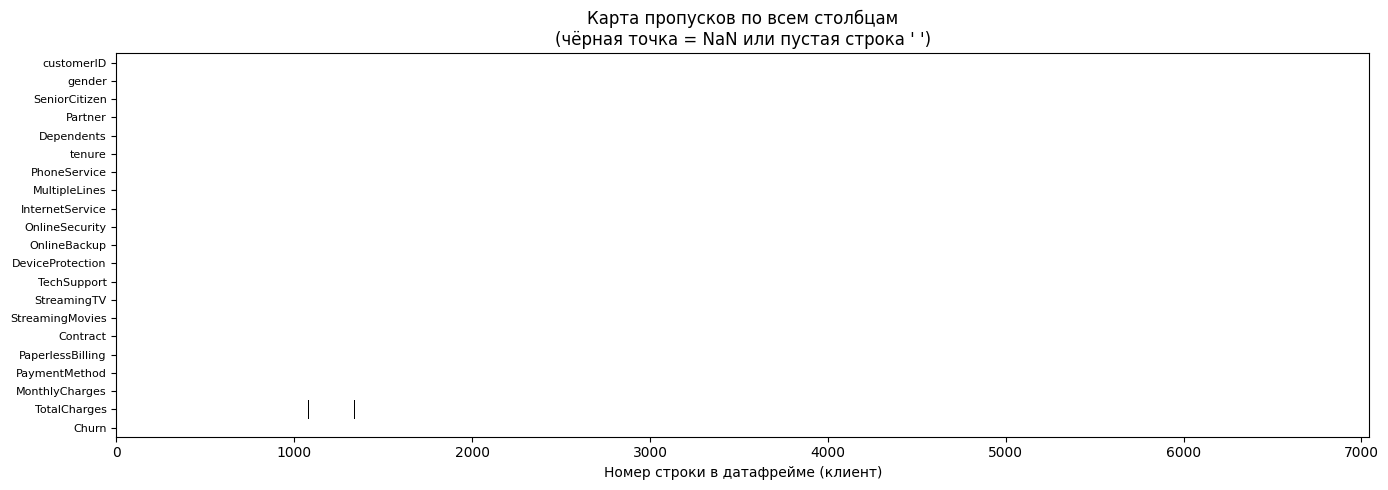

In [217]:
plt.figure(figsize=(14, 5))
plt.imshow(missing_mask.T, aspect='auto', cmap='Greys', interpolation='none')
plt.yticks(range(len(missing_mask.columns)), missing_mask.columns, fontsize=8)
plt.xlabel('Номер строки в датафрейме (клиент)')
plt.title("Карта пропусков по всем столбцам\n(чёрная точка = NaN или пустая строка ' ')")
plt.tight_layout()
plt.show()

In [218]:
hidden_missing_rows = df[df['TotalCharges'] == ' '].index

print(f'Найдено строк со скрытым пропуском: {len(hidden_missing_rows)}')
print('Их индексы в датафрейме:', list(hidden_missing_rows))

df.loc[hidden_missing_rows, ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]

Найдено строк со скрытым пропуском: 11
Их индексы в датафрейме: [488, 753, 936, 1082, 1340, 3331, 3826, 4380, 5218, 6670, 6754]


,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,,No
753,0,20.25,,No
936,0,80.85,,No
1082,0,25.75,,No
1340,0,56.05,,No
3331,0,19.85,,No
3826,0,25.35,,No
4380,0,20.00,,No
5218,0,19.70,,No
6670,0,73.35,,No


**Что видно на графике и в таблице.** На карте пропусков чёрные точки есть только в строке `TotalCharges` — и их ровно 11, как мы и посчитали выше. В таблице видно, что у всех этих 11 клиентов `tenure == 0` (они только что подключились и ещё не получили ни одного счёта — отсюда и пустая сумма). Это и обрабатываем дальше в разделе 5.

## 4. Визуализация: доля оттока
Круговая диаграмма наглядно показывает дисбаланс классов.

**Зачем это знать до моделирования.** Соотношение классов (~73.5% «остался» / ~26.5% «ушёл») — это **дисбаланс**, и он определяет три решения дальше по ноутбуку:

1. **Метрики.** Accuracy обманчива: модель, которая всем подряд говорит «останется», получит accuracy ≈ 73.5%, не найдя ни одного уходящего. Поэтому основные метрики проекта — ROC-AUC и Recall по классу «уйдёт» (разделы 10–15), а не accuracy.
2. **Настройки моделей.** У LogisticRegression включим `class_weight='balanced'`, у бустингов — `scale_pos_weight`: обе настройки увеличивают «штраф» за ошибку на редком классе, заставляя модель обращать на него внимание.
3. **Разбиение выборки.** Train/test split сделаем со `stratify=y`, чтобы пропорция 73.5/26.5 сохранилась в обеих частях (раздел 10).

Два графика показывают одно и то же по-разному: countplot — абсолютные числа (сколько именно клиентов), pie chart — доли (наглядно для презентации).


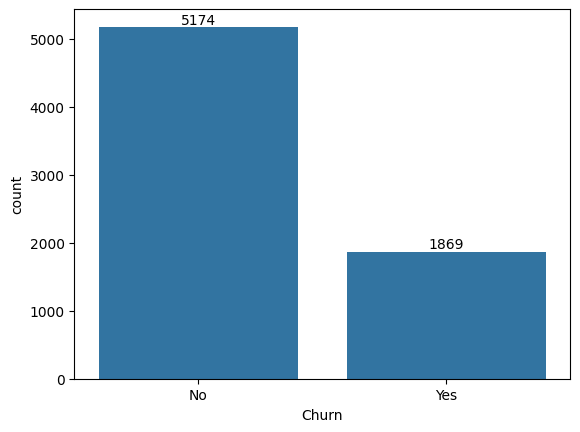

In [219]:
ax = sns.countplot(x='Churn', data=df)
ax.bar_label(ax.containers[0])
plt.show()

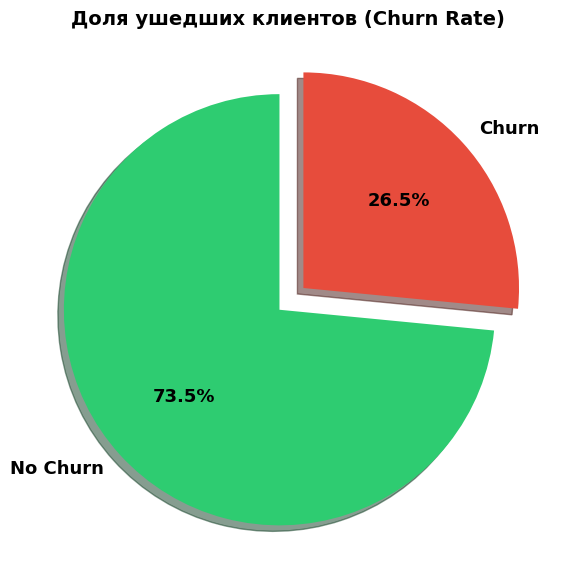

In [220]:
plt.figure(figsize=(7, 7))
plt.pie(churn_counts, 
        labels=['No Churn', 'Churn'],
        autopct='%1.1f%%',
        colors=['#2ecc71', '#e74c3c'],
        explode=(0.05, 0.1),
        shadow=True,
        startangle=90,
        textprops={'fontsize': 13, 'fontweight': 'bold'})
plt.title('Доля ушедших клиентов (Churn Rate)', fontsize=14, fontweight='bold')
plt.show()

## 5. Предобработка данных
- удаляем `customerID` — это идентификатор, а не признак;
- приводим `TotalCharges` к числовому типу;
- убираем клиентов с `tenure == 0` (у них ещё не было счетов, отсюда и пропуски в `TotalCharges`);
- на всякий случай подстраховываемся `fillna(0)`.

In [221]:
df = df.drop('customerID', axis=1)


In [222]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df[df['TotalCharges'].isna()][['tenure', 'MonthlyCharges', 'Churn']]


,tenure,MonthlyCharges,Churn
488,0,52.55,No
753,0,20.25,No
936,0,80.85,No
1082,0,25.75,No
1340,0,56.05,No
3331,0,19.85,No
3826,0,25.35,No
4380,0,20.00,No
5218,0,19.70,No
6670,0,73.35,No


In [223]:
df.drop(labels=df[df['tenure'] == 0].index, axis=0, inplace=True)
df[df['tenure'] == 0].index

Index([], dtype='int64')

In [224]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

### Проверка: пропуски обработаны
Построим ту же самую карту пропусков ещё раз, уже после предобработки. Если всё сделано верно, чёрных точек в `TotalCharges` больше быть не должно.

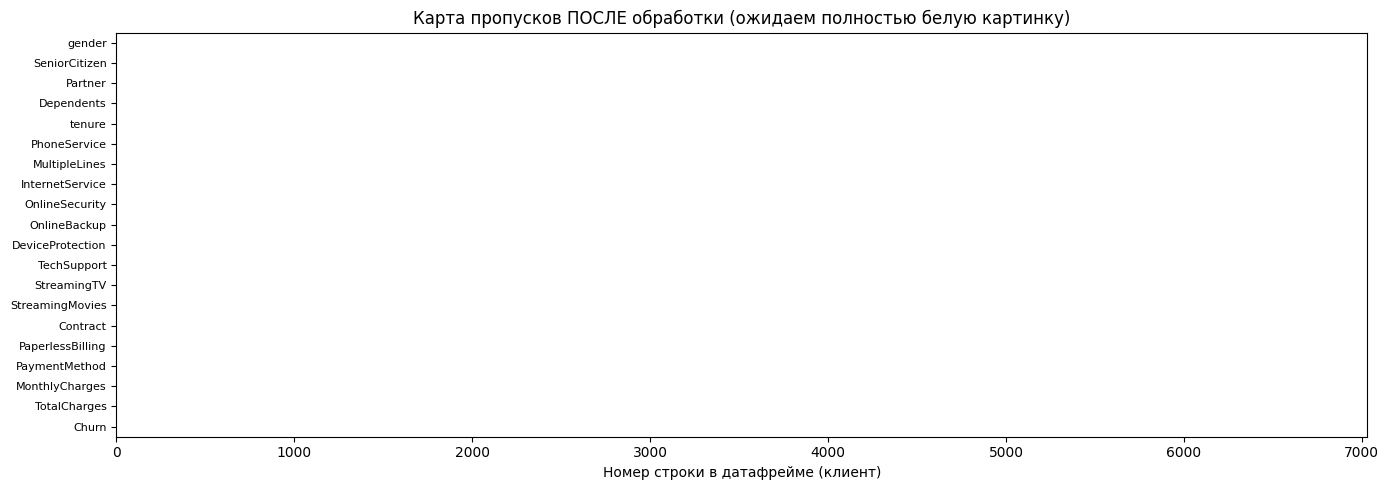

Осталось пропусков всего: 0


In [225]:
missing_mask_after = df.isnull() | (df.astype(str).apply(lambda col: col.str.strip() == ''))

plt.figure(figsize=(14, 5))
plt.imshow(missing_mask_after.T, aspect='auto', cmap='Greys', interpolation='none')
plt.yticks(range(len(missing_mask_after.columns)), missing_mask_after.columns, fontsize=8)
plt.xlabel('Номер строки в датафрейме (клиент)')
plt.title('Карта пропусков ПОСЛЕ обработки (ожидаем полностью белую картинку)')
plt.tight_layout()
plt.show()

print('Осталось пропусков всего:', missing_mask_after.sum().sum())

Проверим результат предобработки.

In [226]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 6. Разведочный анализ (EDA)
### 6.1 Churn rate по категориальным признакам
Для каждого категориального признака (и `SeniorCitizen`) посмотрим долю оттока внутри каждой категории. Это помогает найти сегменты клиентов с повышенным риском ухода.

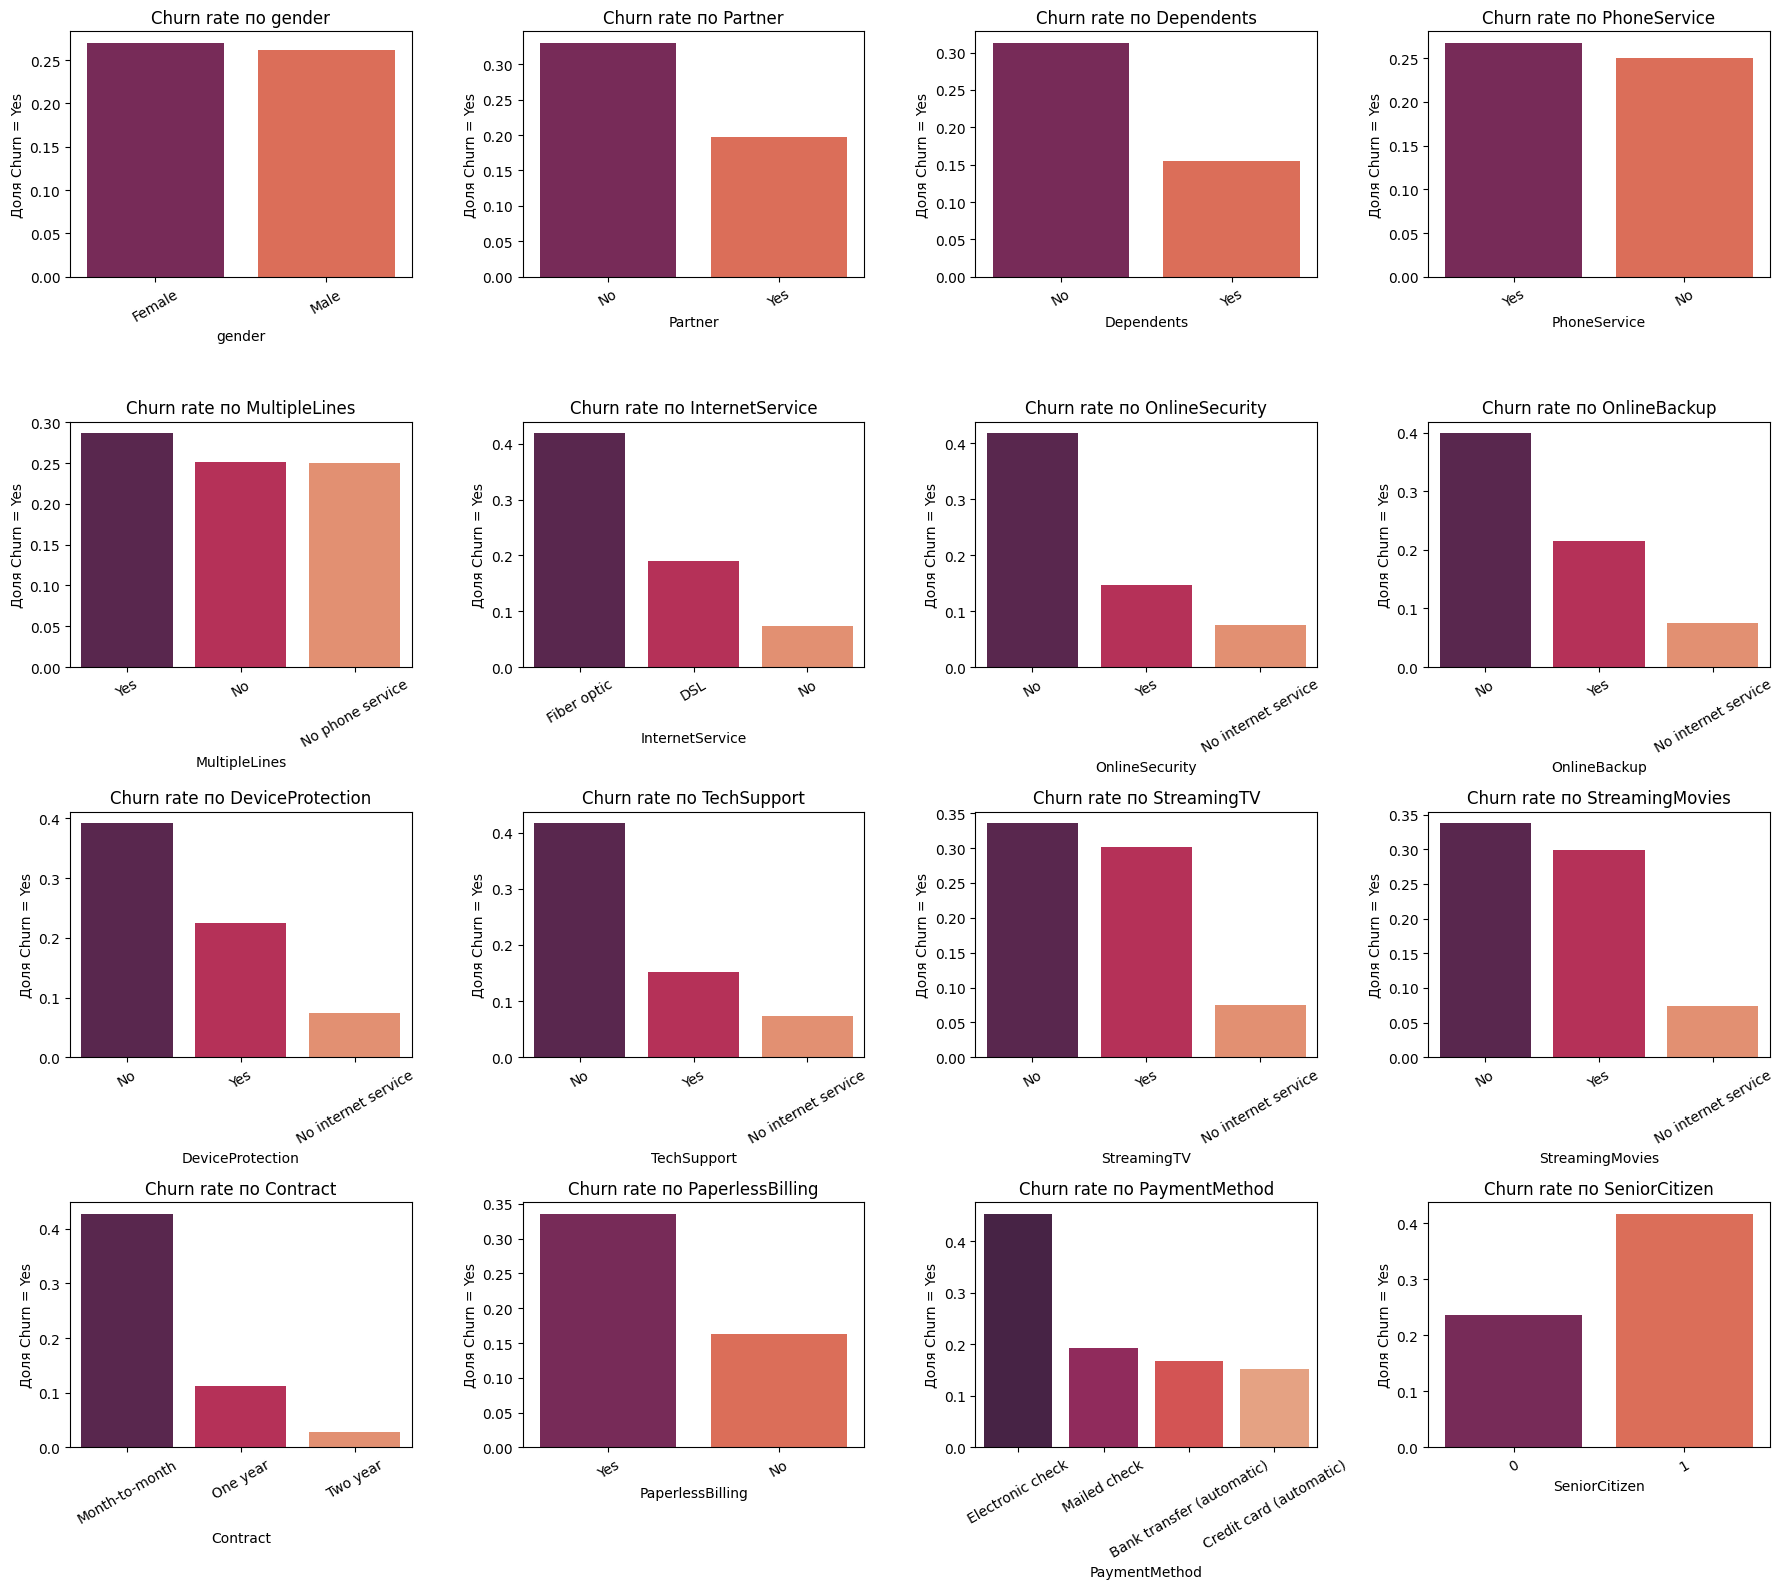

In [227]:
cat_cols_to_check = [c for c in df.select_dtypes(include='object').columns if c != 'Churn']
cat_cols_to_check += ['SeniorCitizen']

n_cols = 4
n_rows = -(-len(cat_cols_to_check) // n_cols)  
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols_to_check):
    rates = df.groupby(col)['Churn'].value_counts(normalize=True).unstack()['Yes']
    rates = rates.sort_values(ascending=False)
    sns.barplot(x=rates.index, y=rates.values, ax=ax, hue=rates.index, palette='rocket', legend=False)
    ax.set_title(f'Churn rate по {col}')
    ax.set_ylabel('Доля Churn = Yes')
    ax.tick_params(axis='x', rotation=30)

for ax in axes[len(cat_cols_to_check):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


### 6.1b Ранжирование категориальных признаков по силе связи с Churn (χ² / Cramér's V)

Барплоты выше показывают churn rate *внутри* каждой категории, но не показывают, насколько сильна связь признака с оттоком в целом — и не позволяют сравнивать признаки друг с другом объективно, а не "на глаз по высоте столбиков".

**Как это работает:**
1. Для каждого признака строим таблицу сопряжённости (`crosstab`) "категория × Churn".
2. Считаем **χ² (хи-квадрат)** — насколько наблюдаемое распределение отличается от того, что было бы при полной независимости признака и Churn. Чем больше χ², тем сильнее связь — но χ² растёт вместе с размером выборки и числом категорий, поэтому напрямую сравнивать χ² разных признаков нельзя.
3. Нормируем χ² в **Cramér's V** — значение от 0 (нет связи) до 1 (полная связь), уже сравнимое между всеми признаками независимо от числа их категорий.

**Зачем именно это, а не просто барплоты:** признак с редкой категорией, где визуально "отток зашкаливает", может держаться на 15 наблюдениях и быть статистическим шумом — барплот это не покажет, а p-value и Cramér's V покажут. Это даёт объективное ранжирование признаков и хорошо дополняет feature importance модели в конце ноутбука (там оценка уже *после* обучения и one-hot encoding, а здесь — сырой, model-agnostic взгляд *до* моделирования).

In [228]:
from scipy.stats import chi2_contingency

def cramers_v(chi2, confusion_matrix):
    """Cramér's V: нормированная сила связи (0 = нет связи, 1 = полная связь).

    Функция принимает УЖЕ посчитанную статистику chi2, а не вычисляет её заново:
    chi2_contingency — самая дорогая операция в этой ячейке, и раньше она
    выполнялась дважды для каждого признака (один раз ради p-value в цикле,
    второй раз внутри cramers_v). Результат был тот же, просто в два раза
    больше работы — классический пример лишнего пересчёта, который легко
    убрать, передав готовое значение параметром.
    """
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt((chi2 / n) / (min(r, k) - 1))

assoc_results = []
for col in cat_cols_to_check:
    ct = pd.crosstab(df[col], df['Churn'])
    chi2, p_value, dof, expected = chi2_contingency(ct)  
    v = cramers_v(chi2, ct)                              
    assoc_results.append({'feature': col, 'cramers_v': v, 'p_value': p_value})

assoc_df = pd.DataFrame(assoc_results).sort_values('cramers_v', ascending=False).reset_index(drop=True)
assoc_df

,feature,cramers_v,p_value
0,Contract,0.409560,7.326182e-257
1,OnlineSecurity,0.346992,1.400687e-184
2,TechSupport,0.342506,7.407808e-180
3,InternetService,0.321909,5.831199e-159
4,PaymentMethod,0.302960,1.426310e-139
5,OnlineBackup,0.291902,7.776099e-131
6,DeviceProtection,0.281159,1.959389e-121
7,StreamingMovies,0.230702,5.353560e-82
8,StreamingTV,0.230143,1.324641e-81
9,PaperlessBilling,0.191127,8.236203e-58


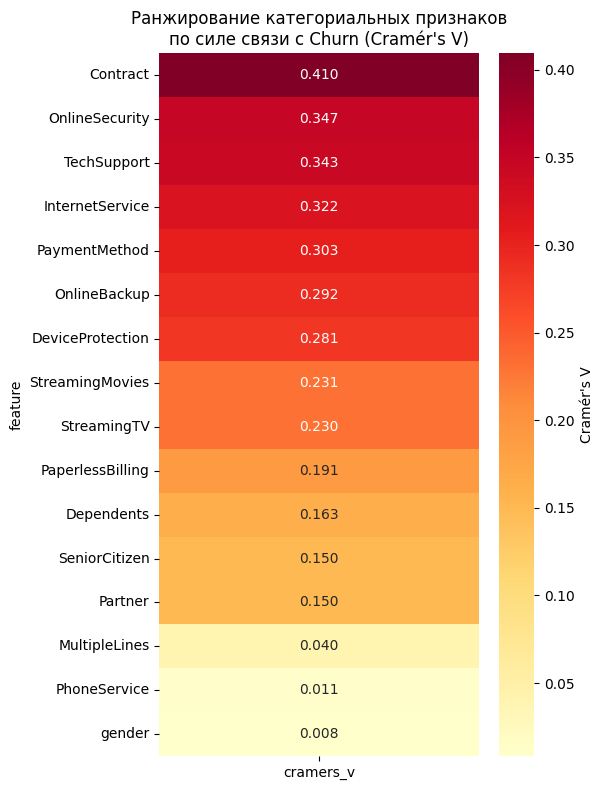

In [229]:
plt.figure(figsize=(6, 8))
sns.heatmap(
    assoc_df.set_index('feature')[['cramers_v']],
    annot=True, fmt='.3f', cmap='YlOrRd',
    cbar_kws={'label': "Cramér's V"}
)
plt.title("Ранжирование категориальных признаков\nпо силе связи с Churn (Cramér's V)")
plt.tight_layout()
plt.show()

### 6.2 Новые агрегаты для анализа
Прежде чем перейти к моделированию, создадим пару вспомогательных признаков и посмотрим на связи в данных:
- `num_services` — сколько доп. услуг подключено;
- `has_family` — есть партнёр или иждивенцы.

In [230]:
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                 'TechSupport', 'StreamingTV', 'StreamingMovies']
df['num_services'] = (df[service_cols] == 'Yes').sum(axis=1)

In [231]:
df['has_family'] = ((df['Partner']=='Yes') | (df['Dependents']=='Yes')).astype(int)

Матрица оттока по типу контракта и способу оплаты — ищем «опасные» комбинации.

In [232]:
pd.crosstab(df['Contract'], df['PaymentMethod'], values=df['Churn']=='Yes', aggfunc='mean')

PaymentMethod,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
Contract,,,,
Month-to-month,0.341256,0.327808,0.537297,0.315789
One year,0.097187,0.103015,0.184438,0.068452
Two year,0.033808,0.022414,0.077381,0.008000


In [233]:
df['high_risk_combo'] = ((df['Contract']=='Month-to-month') & (df['PaymentMethod']=='Electronic check')).astype(int)

**Честная методологическая оговорка про `high_risk_combo`.**

Мы только что *сконструировали признак, глядя на таргет*: комбинация «Month-to-month + Electronic check» выбрана глазами по матрице churn rate, посчитанной на **полном датасете** — включая те 20% клиентов, которые в разделе 10 станут тестовой выборкой. Это лёгкая форма **утечки данных (data leakage) на уровне отбора признаков**: решение «какая комбинация опасная» принято с подглядыванием в тест, поэтому тестовая оценка моделей становится чуть-чуть оптимистичной.

Почему здесь это не катастрофа:

- мы не использовали сами ответы тестовых клиентов при обучении — только при выборе *дизайна* признака;
- комбинация «месячный контракт + electronic check» — общеизвестный факт этого датасета и телеком-домена в целом, она была бы выбрана и по одной train-части;
- признак малокардинальный (один бинарный флаг), масштаб возможного смещения — доли тысячных AUC.

Почему об этом всё равно обязательно писать: **строго правильная процедура** — сначала отложить тест (раздел 10), а уже потом искать «опасные комбинации» только по train-части; в продовом пайплайне отбор признаков вообще должен происходить внутри кросс-валидации. Отсюда общее правило, которое ещё дважды вернётся в этом ноутбуке (разделы 14.1 и 17): **любое решение, принятое по данным — отбор признаков, гиперпараметры, порог классификации, — должно приниматься без участия теста. Тест трогаем один раз, для финальной цифры.**

Средний ежемесячный платёж по типу интернет-услуги.

In [234]:
df.groupby('InternetService')['MonthlyCharges'].mean()

InternetService
DSL            58.088017
Fiber optic    91.500129
No             21.076283
Name: MonthlyCharges, dtype: float64

### 6.3 Распределения числовых признаков
Гистограммы `tenure`, `MonthlyCharges`, `TotalCharges` в разрезе Churn.

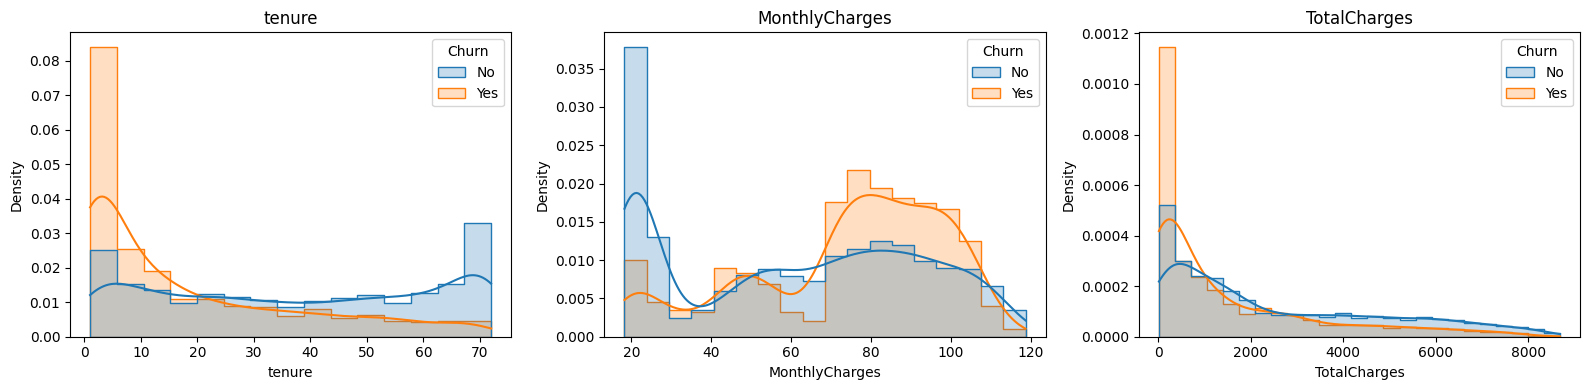

In [235]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    sns.histplot(data=df, x=col, hue='Churn', kde=True, ax=ax, element='step', stat='density', common_norm=False)
    ax.set_title(col)

plt.tight_layout()
plt.show()


Boxplot тех же признаков — удобно сравнивать медианы и разброс между группами.

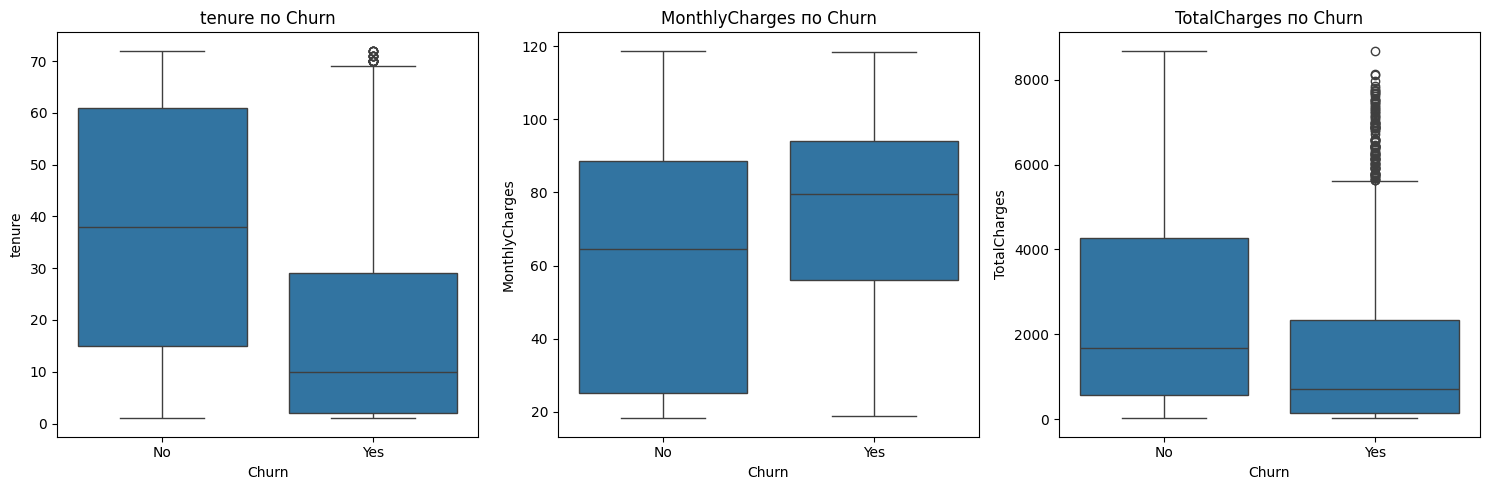

In [236]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
for ax, col in zip(axes, num_cols):
    sns.boxplot(data=df, x='Churn', y=col, ax=ax)
    ax.set_title(f'{col} по Churn')
plt.tight_layout()
plt.show()

### 6.4 Scatter plot: `tenure` vs `MonthlyCharges` (цвет = `Churn`)

До этого момента мы смотрели на `tenure`, `MonthlyCharges` и `TotalCharges` **по отдельности** (гистограммы и boxplot в 6.3). Это удобно, чтобы понять форму распределения каждого признака отдельно, но такой подход не показывает, **как признаки ведут себя вместе**.

Диаграмма рассеяния (scatter plot) двух числовых признаков с цветом по категориальному таргету — стандартный EDA-приём, когда нужно понять:
- есть ли в данных **визуальные кластеры** (группы точек), которые не видны при взгляде на один признак;
- как **распределение оттока меняется в двумерном пространстве** признаков, а не только по каждой оси;
- нет ли **нелинейного взаимодействия** между двумя признаками, которое не ловится обычной корреляцией.

Именно такой кластер здесь и находится: "новые клиенты (маленький `tenure`) с высоким ежемесячным чеком (`MonthlyCharges`)" — зона повышенного оттока, которую не видно ни на одной гистограмме по отдельности.

#### Как это работает "вручную", шаг за шагом

Под капотом `sns.scatterplot(..., hue='Churn')` делает то же самое, что можно написать руками через `matplotlib`. Разберём по шагам, что происходит:

1. **Берём координаты.** Для каждого клиента `i` в таблице у нас есть пара чисел `(x_i, y_i) = (tenure_i, MonthlyCharges_i)`. Это координаты точки на плоскости.
2. **Делим клиентов на группы по `Churn`.** Получаем два подмножества индексов: те, у кого `Churn == 'Yes'`, и те, у кого `Churn == 'No'`.
3. **Каждой группе назначаем свой цвет/маркер.** Например, "No" → синий, "Yes" → оранжевый (или любая другая пара контрастных цветов).
4. **Рисуем каждую группу отдельным вызовом `scatter`**, передавая в него только координаты `x` и `y` точек этой группы и выбранный цвет. Порядок вызовов не важен — они просто накладываются на одни оси.
5. **Настраиваем прозрачность (`alpha`).** Так как точек тысячи и они перекрываются, прозрачность позволяет увидеть *плотность* — там, где точки одного цвета накладываются друг на друга много раз, область выглядит темнее/насыщеннее.
6. **Добавляем подписи осей, заголовок и легенду**, чтобы график был читаем без обращения к коду.

То есть весь смысл `hue='Churn'` в seaborn — это автоматизация шагов 2–4: seaborn сам группирует данные по значению столбца и рисует каждую группу своим цветом. Ячейка ниже показывает эквивалент "руками", без `hue`, чтобы был виден этот механизм явно.

Ниже — тот же график, но через `seaborn`, одной строкой (`hue='Churn'` берёт на себя шаги 2–4 из разбора выше). Это и есть финальная версия для отчёта.

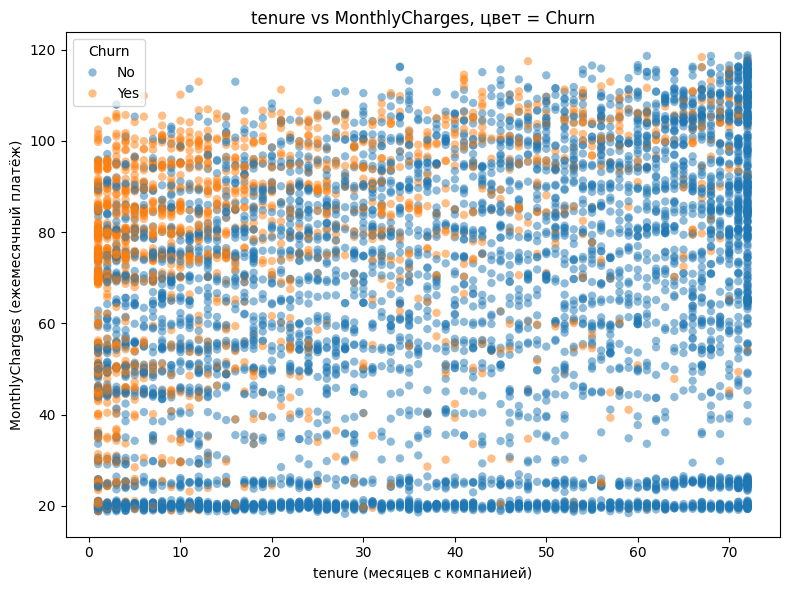

In [237]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x='tenure',
    y='MonthlyCharges',
    hue='Churn',
    alpha=0.5,
    edgecolor='none'
)
plt.title('tenure vs MonthlyCharges, цвет = Churn')
plt.xlabel('tenure (месяцев с компанией)')
plt.ylabel('MonthlyCharges (ежемесячный платёж)')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()


**Что видно на графике.** В левой части графика (маленький `tenure`, то есть новые клиенты) точки с `Churn = Yes` заметно гуще концентрируются в верхней части по `MonthlyCharges` — то есть среди новых клиентов чаще уходят те, кто сразу платит много. Справа (клиенты с большим стажем) оранжевых точек заметно меньше независимо от уровня платежа — стаж работает как "якорь", удерживающий клиента. Эта комбинация ("новый + дорогой тариф = высокий риск ухода") — готовая гипотеза для отдела продаж и для будущего признака в Feature Engineering (раздел 7), например `is_new_customer` уже добавлен туда с похожей логикой.

#### Почему именно scatter plot, а не другой метод

| Метод | Что показывает | Почему здесь хуже scatter |
|---|---|---|
| Гистограмма / KDE по одному признаку (уже сделано в 6.3) | Форму распределения **одного** признака в разрезе Churn | Не показывает **взаимодействие** двух признаков — кластер "новый + дорогой" физически не виден, если смотреть на `tenure` и `MonthlyCharges` по отдельности |
| Boxplot (уже сделано в 6.3) | Медиану и разброс одного признака по группам | Ещё сильнее агрегирует данные, чем гистограмма; полностью прячет форму и плотность облака точек, а также любые подгруппы внутри категории |
| Матрица корреляций (раздел 9) | Линейную связь между парой числовых признаков одним числом | `tenure` и `MonthlyCharges` слабо коррелируют между собой линейно, поэтому корреляция ничего не скажет о найденном кластере — задача не линейная, а "зона в углу графика" |
| 2D KDE / hexbin (плотность вместо точек) | Общую плотность распределения без деления по группам | Хорошо показывает форму облака, но так же, как heatmap, требует отдельного слоя на каждый класс `Churn`, а с двумя перекрывающимися KDE читать становится сложнее, чем raw scatter с прозрачностью; вдобавок обычные точки честно показывают выбросы и реальный размер выборки, а плотностная оценка их сглаживает |
| PCA / снижение размерности | Общую структуру данных по многим признакам сразу | Оверкилл для двух конкретных, уже интерпретируемых признаков — оси PCA теряют единицы измерения (месяцы, доллары) и понятность для нетехнического читателя отчёта |
| 3D scatter (добавить третью ось, например `TotalCharges`) | То же самое + ещё одно измерение | На статичном 2D-изображении (как в ноутбуке/отчёте) 3D-график страдает от наложения точек и субъективного угла обзора; тот же эффект обычно проще показать через размер/цвет точки (доп. канал), а не через третью пространственную ось |

**Итог:** для двух непрерывных признаков (`tenure`, `MonthlyCharges`) и одного категориального таргета (`Churn`) scatter plot с `hue` — минимально сложный метод, который сохраняет исходные единицы измерения, честно показывает каждую точку данных (а не агрегат) и напрямую отвечает на вопрос "есть ли зона повышенного риска на пересечении двух признаков?". Более простые методы (гистограмма, boxplot, корреляция) не видят двумерного взаимодействия, а более сложные (PCA, 3D) добавляют издержки на интерпретацию без выигрыша в информативности при всего двух осях.

## 7. Feature Engineering
Добавляем производные признаки, которые могут усилить сигнал для модели:
- `tenure_group` / `is_new_customer` — группировка по стажу;
- `charges_group` — группировка по уровню платежа;
- `charges_diff` — расхождение между "ожидаемой" суммой (`tenure * MonthlyCharges`) и фактической `TotalCharges`.
- **(7.1)** признаки-взаимодействия: `tenure_x_services`, `charges_per_service`, `has_internet_and_phone`, `services_share` — подробный разбор ниже.


In [238]:
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 60, 72],
    labels=['0-12', '13-24', '25-48', '49-60', '61-72'],
    include_lowest=True
)

df['is_new_customer'] = (df['tenure'] < 12).astype(int)

In [239]:
df['charges_group'] = pd.cut(
    df['MonthlyCharges'],
    bins=[0, 35, 70, 120],
    labels=['low', 'mid', 'high'],
    include_lowest=True
)

In [240]:
df['charges_diff'] = (df['tenure'] * df['MonthlyCharges']) - df['TotalCharges']

### 7.1 Признаки-взаимодействия (feature interactions)

До этого момента наш feature engineering был довольно скромным: группировки (`tenure_group`, `charges_group`), бинарные флаги (`is_new_customer`, `has_family`, `high_risk_combo`) и одна арифметическая производная (`charges_diff`). Все эти признаки построены **из одного-двух исходных столбцов по отдельности** и почти не описывают, как признаки *взаимодействуют* друг с другом.

**Что такое признак-взаимодействие и зачем он нужен.** Взаимодействие — это ситуация, когда влияние одного признака на таргет *зависит от значения другого* признака. Классический пример из нашего же EDA (раздел 6.4): высокий `MonthlyCharges` сам по себе — умеренный фактор риска, маленький `tenure` — тоже, но их **комбинация** («новый клиент + дорогой тариф») даёт непропорционально высокий отток. Линейные модели (наша LogisticRegression) физически не способны выучить такое сами: они складывают вклады признаков независимо. Деревья и бустинги (CatBoost, LightGBM) *могут* находить взаимодействия через последовательные сплиты, но явная подача готового взаимодействия:
- экономит модели «глубину» — нужный сигнал доступен за один сплит, а не за цепочку из двух-трёх;
- делает сигнал доступным и для линейной baseline-модели, выравнивая сравнение моделей;
- даёт интерпретируемые признаки, которые потом видны в feature importance под понятным именем.

**Какие именно признаки добавляем и почему именно их:**

1. **`tenure_x_services = tenure × num_services`** — «накопленная вовлечённость». Клиент, который *давно* с компанией **и** пользуется *многими* услугами, максимально «врос» в экосистему — у него высокая стоимость переключения на конкурента. Ни `tenure`, ни `num_services` по отдельности этого не выражают: новичок с 6 услугами и ветеран с 0 услуг могут иметь одинаковый риск, но по разным причинам, а произведение чётко отделяет «вросших» (большое значение) от всех остальных (малое). Это прямое продолжение вывода из scatter plot 6.4, где `tenure` работал как «якорь».

2. **`charges_per_service = MonthlyCharges / num_services`** — «цена за одну услугу», нормировка платежа на объём получаемого. Абсолютный платёж 90$ — это дорого или нет? Зависит от того, что клиент за него получает: 90$ за 6 услуг — выгодный пакет, 90$ за 1 услугу — ощущение переплаты, а именно *ощущение несправедливой цены* — классический драйвер оттока. Признак превращает «сколько платит» в «насколько оправданно платит». Технически: у части клиентов `num_services == 0`, поэтому в знаменателе используем `num_services + 1` (плавная защита от деления на ноль; альтернатива `replace(0, np.nan)` создала бы новые пропуски, которые мы только что вычистили в разделе 5).

3. **`has_internet_and_phone`** — флаг «есть и интернет, и телефон». Это признак *ширины* подключения к базовым продуктам (а `num_services` считает только дополнительные услуги поверх них). Гипотеза та же, что и в п.1 — мультипродуктовый клиент сильнее привязан: уйти к конкуренту означает перенести сразу два сервиса, а не один. Кроме того, в EDA 6.1 видно, что churn rate сильно различается по `InternetService` и `PhoneService` по отдельности — их пересечение может нести дополнительный сигнал, который one-hot кодирование этих столбцов по отдельности не выразит.

4. **`services_share = num_services / 6`** — доля подключённых дополнительных услуг от максимума (всего их 6: `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`). По сути это нормированная версия `num_services` в диапазоне [0, 1]. Зачем она, если `num_services` уже есть: (а) масштаб [0, 1] удобен для линейной модели со стандартизацией и делает коэффициент напрямую интерпретируемым («переход от 0% к 100% услуг меняет лог-шанс оттока на β»); (б) это «страховка» на будущее — если набор услуг в данных изменится, доля останется сопоставимой между версиями датасета; (в) для деревьев признак почти эквивалентен `num_services`, то есть вреда не наносит, а отбор признаков потом покажет, какой вариант полезнее.

**Почему мы не боимся, что новые признаки «дублируют» старые.** `tenure_x_services` скоррелирован и с `tenure`, и с `num_services`, `services_share` — с `num_services` и т.д. Для бустингов мультиколлинеарность практически безвредна (дерево просто выберет более информативный сплит), для LogisticRegression у нас есть L2-регуляризация (подбирается по `C` в GridSearch, раздел 11), которая гасит проблему раздутых коэффициентов. При этом сильно скоррелированные пары мы отдельно проверяем в разделе 9.1 — новые признаки автоматически попадут в ту проверку.

**Что мы ожидаем от этих признаков.** Не гарантированного роста метрик — это гипотезы, сформулированные из EDA и бизнес-логики удержания клиентов. Честная проверка — сравнить ROC-AUC/Recall моделей до и после добавления и посмотреть, попали ли новые признаки в топ feature importance (последний раздел ноутбука). Если признак окажется бесполезным, модель его просто проигнорирует (бустинги) или занулит коэффициент (регуляризованная регрессия).

In [241]:
df['tenure_x_services'] = df['tenure'] * df['num_services']

df['charges_per_service'] = df['MonthlyCharges'] / (df['num_services'] + 1)

df['has_internet_and_phone'] = (
    (df['PhoneService'] == 'Yes') & (df['InternetService'] != 'No')
).astype(int)

df['services_share'] = df['num_services'] / len(service_cols)

df[['tenure', 'num_services', 'MonthlyCharges',
    'tenure_x_services', 'charges_per_service',
    'has_internet_and_phone', 'services_share']].head(10)

,tenure,num_services,MonthlyCharges,tenure_x_services,charges_per_service,has_internet_and_phone,services_share
0,1,1,29.85,1,14.925000,0,0.166667
1,34,2,56.95,68,18.983333,1,0.333333
2,2,2,53.85,4,17.950000,1,0.333333
3,45,3,42.30,135,10.575000,0,0.500000
4,2,0,70.70,0,70.700000,1,0.000000
5,8,3,99.65,24,24.912500,1,0.500000
6,22,2,89.10,44,29.700000,1,0.333333
7,10,1,29.75,10,14.875000,0,0.166667
8,28,4,104.80,112,20.960000,1,0.666667
9,62,2,56.15,124,18.716667,1,0.333333


#### Быстрая проверка: несут ли новые признаки сигнал об оттоке

Прежде чем отдавать признаки модели, сделаем минимальную «санитарную» проверку — сравним их средние значения в группах `Churn = Yes` и `Churn = No`. Это не строгий статистический тест, а быстрый способ убедиться, что признаки (а) корректно посчитаны и (б) хотя бы в среднем различаются между классами — то есть модели есть за что зацепиться. Для флага `has_internet_and_phone` дополнительно посмотрим churn rate внутри каждой из двух групп — так же, как делали для категориальных признаков в 6.1.

In [242]:
new_feats = ['tenure_x_services', 'charges_per_service', 'has_internet_and_phone', 'services_share']

print(df.groupby('Churn')[new_feats].mean().round(3))

print('\nChurn rate по has_internet_and_phone:')
print(df.groupby('has_internet_and_phone')['Churn']
        .value_counts(normalize=True).unstack()['Yes'].round(3))

       tenure_x_services  charges_per_service  has_internet_and_phone  \
Churn                                                                   
No               102.962               22.796                   0.629   
Yes               48.675               32.977                   0.849   

       services_share  
Churn                  
No              0.356  
Yes             0.295  

Churn rate по has_internet_and_phone:
has_internet_and_phone
0    0.129
1    0.328
Name: Yes, dtype: float64


**Как читать результат.** Если у `tenure_x_services` среднее заметно выше в группе `Churn = No` — гипотеза «вовлечённость удерживает» подтверждается на уровне данных. Если `charges_per_service` выше у ушедших — работает гипотеза «переплата за малый объём услуг подталкивает к уходу». Итоговую же ценность признаков покажут метрики моделей и feature importance в конце ноутбука.

Проверим таблицу с новыми признаками.

In [243]:
df.head(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,has_family,high_risk_combo,tenure_group,is_new_customer,charges_group,charges_diff,tenure_x_services,charges_per_service,has_internet_and_phone,services_share
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,1,1,0-12,1,low,0.00,1,14.925000,0,0.166667
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,0,0,25-48,0,mid,46.80,68,18.983333,1,0.333333
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,0,0,0-12,1,mid,-0.45,4,17.950000,1,0.333333
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,0,0,25-48,0,mid,62.75,135,10.575000,0,0.500000
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,0,1,0-12,1,high,-10.25,0,70.700000,1,0.000000
5,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,...,0,1,0-12,1,high,-23.30,24,24.912500,1,0.500000
6,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,...,1,0,13-24,0,high,10.80,44,29.700000,1,0.333333
7,Female,0,No,No,10,No,No phone service,DSL,Yes,No,...,0,0,0-12,1,low,-4.40,10,14.875000,0,0.166667
8,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,...,1,1,25-48,0,high,-111.65,112,20.960000,1,0.666667
9,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,...,1,0,61-72,0,mid,-6.65,124,18.716667,1,0.333333


In [244]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   gender                  7032 non-null   object  
 1   SeniorCitizen           7032 non-null   int64   
 2   Partner                 7032 non-null   object  
 3   Dependents              7032 non-null   object  
 4   tenure                  7032 non-null   int64   
 5   PhoneService            7032 non-null   object  
 6   MultipleLines           7032 non-null   object  
 7   InternetService         7032 non-null   object  
 8   OnlineSecurity          7032 non-null   object  
 9   OnlineBackup            7032 non-null   object  
 10  DeviceProtection        7032 non-null   object  
 11  TechSupport             7032 non-null   object  
 12  StreamingTV             7032 non-null   object  
 13  StreamingMovies         7032 non-null   object  
 14  Contract                7032 

## 8. Кодирование категориальных признаков

Модели машинного обучения работают с **числами**: LogisticRegression перемножает признаки на коэффициенты, деревья сравнивают значения с порогами. Строку `'Month-to-month'` ни умножить, ни сравнить «больше/меньше» нельзя — поэтому все текстовые признаки нужно перевести в числа. Делаем это двумя разными способами в зависимости от числа категорий:

- **2 категории** (Yes/No, Male/Female) → простое отображение в 0/1 (раздел 8.1). Никакой информации не теряется: один бит — один столбец.
- **3+ категорий** (Contract, PaymentMethod, ...) → one-hot encoding (раздел 8.2). Просто пронумеровать категории `0, 1, 2` нельзя — модель решила бы, что между ними есть порядок и расстояние («Two year» вдвое больше «One year»?), которых на самом деле нет.

### 8.1 Бинарные признаки (Yes/No, Male/Female) → 0/1

`.map({'Yes': 1, 'No': 0})` заменяет каждое значение по словарю. Важный побочный эффект, о котором стоит помнить: если в столбце встретится значение, которого нет в словаре (опечатка, новая категория), `map` вернёт для него `NaN` — поэтому сразу после кодирования печатаем `unique()` каждого столбца и проверяем, что там только `[0, 1]` и нет неожиданных `NaN`.


In [245]:
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})


In [246]:
for col in binary_cols + ['gender']:
    print(f"{col}: {df[col].unique()}")


Partner: [1 0]
Dependents: [0 1]
PhoneService: [0 1]
PaperlessBilling: [1 0]
Churn: [0 1]
gender: [0 1]


Проверим, какие признаки ещё остались нечисловыми и сколько в них уникальных категорий.

In [247]:
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].nunique()} уникальных -> {df[col].unique()}")


MultipleLines: 3 уникальных -> ['No phone service' 'No' 'Yes']
InternetService: 3 уникальных -> ['DSL' 'Fiber optic' 'No']
OnlineSecurity: 3 уникальных -> ['No' 'Yes' 'No internet service']
OnlineBackup: 3 уникальных -> ['Yes' 'No' 'No internet service']
DeviceProtection: 3 уникальных -> ['No' 'Yes' 'No internet service']
TechSupport: 3 уникальных -> ['No' 'Yes' 'No internet service']
StreamingTV: 3 уникальных -> ['No' 'Yes' 'No internet service']
StreamingMovies: 3 уникальных -> ['No' 'Yes' 'No internet service']
Contract: 3 уникальных -> ['Month-to-month' 'One year' 'Two year']
PaymentMethod: 4 уникальных -> ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


### 8.2 One-Hot Encoding для многоклассовых категориальных признаков

**Как работает one-hot:** признак с *k* категориями разворачивается в *k* бинарных столбцов-«флагов». `Contract` со значениями `Month-to-month / One year / Two year` превращается в столбцы `Contract_One year` и `Contract_Two year` (0 или 1).

**Зачем `drop_first=True`:** первая категория не получает своего столбца — она кодируется как «все нули». Если оставить все *k* столбцов, они в сумме всегда дают 1, то есть любой из них линейно выражается через остальные (это называют *dummy trap* — полная мультиколлинеарность). Для линейной регрессии это делает коэффициенты неустойчивыми; удаление одного столбца проблему снимает, не теряя информации.

**Зачем `.astype(int)` после:** `pd.get_dummies` создаёт столбцы типа `bool` (True/False); приводим их к 0/1 для единообразия с остальными числовыми признаками.


**Сохраняем копию датафрейма с сырыми категориями.** Ниже мы закодируем многоклассовые признаки через one-hot — это нужно для LogisticRegression и LightGBM. Но CatBoost умеет работать с категориями *нативно*, без one-hot, и это обычно даёт прирост качества (см. раздел 12.1). Чтобы потом было из чего обучать «нативный» CatBoost, откладываем копию датафрейма до кодирования.


In [248]:
df_raw_cat = df.copy()


In [249]:
multi_cat_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity',
                   'OnlineBackup', 'DeviceProtection', 'TechSupport',
                   'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod',
                   'tenure_group', 'charges_group'] 

df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)
dummy_cols = [c for c in df.columns if df[c].dtype == 'bool']
df[dummy_cols] = df[dummy_cols].astype(int)


## 9. Финальная проверка данных перед моделированием

Контрольная точка перед разбиением на train/test. После всех преобразований (чистка → новые признаки → кодирование) датафрейм сильно изменился, и прежде чем «замораживать» его для моделей, проверяем три вещи:

1. `df.info()` — **все** столбцы теперь числовые (int/float), пропусков нет. Если остался хоть один `object`-столбец, sklearn упадёт при обучении.
2. `value_counts(normalize=True)` по таргету — пропорция классов не «уехала» после удаления строк в разделе 5.
3. `groupby('Churn').describe()` — базовые статистики ключевых числовых признаков в разрезе классов: быстрый способ убедиться, что различия между группами (которые мы видели в EDA) никуда не делись после преобразований.

Затем смотрим корреляции — сначала между тремя «сырыми» числовыми признаками, потом (9.1) по всей матрице.


In [250]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 46 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7032 non-null   int64  
 1   SeniorCitizen                          7032 non-null   int64  
 2   Partner                                7032 non-null   int64  
 3   Dependents                             7032 non-null   int64  
 4   tenure                                 7032 non-null   int64  
 5   PhoneService                           7032 non-null   int64  
 6   PaperlessBilling                       7032 non-null   int64  
 7   MonthlyCharges                         7032 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7032 non-null   int64  
 10  num_services                           7032 non-null   int64  
 11  has_famil

In [251]:
df['Churn'].value_counts(normalize=True)


Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64

In [252]:
df.groupby('Churn')[['tenure', 'MonthlyCharges', 'TotalCharges']].describe()


tenure                                                     \
        count       mean        std  min   25%   50%   75%   max   
Churn                                                              
0      5163.0  37.650010  24.076940  1.0  15.0  38.0  61.0  72.0   
1      1869.0  17.979133  19.531123  1.0   2.0  10.0  29.0  72.0   

      MonthlyCharges             ...                 TotalCharges  \
               count       mean  ...     75%     max        count   
Churn                            ...                                
0             5163.0  61.307408  ...  88.475  118.75       5163.0   
1             1869.0  74.441332  ...  94.200  118.35       1869.0   

                                                                             
              mean          std    min      25%      50%       75%      max  
Churn                                                                        
0      2555.344141  2329.456984  18.80  577.825  1683.60  4264.125  8672.45  
1      1531.796094  1890.822994  18.85  134.500   703.55  2331.300  8684.80  

[2 rows x 24 columns]

Корреляция между ключевыми числовыми признаками.

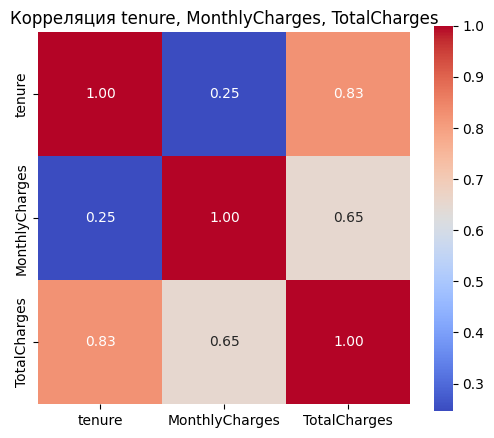

In [253]:
core_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
plt.figure(figsize=(6, 5))
sns.heatmap(df[core_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Корреляция tenure, MonthlyCharges, TotalCharges')
plt.show()


### 9.1 Полная корреляционная матрица (все числовые + dummy-признаки)
Матрица выше (`tenure`, `MonthlyCharges`, `TotalCharges`) полезна, но охватывает только 3 «сырых» признака.
После `pd.get_dummies` и Feature Engineering в датафрейме уже десятки числовых/бинарных колонок,
и часть из них — производные друг от друга. Это важно проверить **до** обучения линейных моделей
(LogisticRegression), т.к. сильная мультиколлинеарность делает коэффициенты модели нестабильными
и плохо интерпретируемыми (на деревьях/бустинге — CatBoost, LightGBM — эффект слабее, но признаки
всё равно избыточны и раздувают важность друг друга).

Строим корреляцию Пирсона по всем числовым столбцам (dummy-колонки 0/1 после `get_dummies` для этого
метода — валидный частный случай, phi-coefficient). Отдельно выведем только пары с |corr| > 0.8,
чтобы не тонуть в огромной матрице — ожидаемые кандидаты: `charges_diff` эта разница
`tenure * MonthlyCharges - TotalCharges`, поэтому по построению почти линейно зависит от всех трёх;
`num_services` — сумма 6 dummy-флагов (`OnlineSecurity_Yes` и т.д.), поэтому коррелирует с ними.

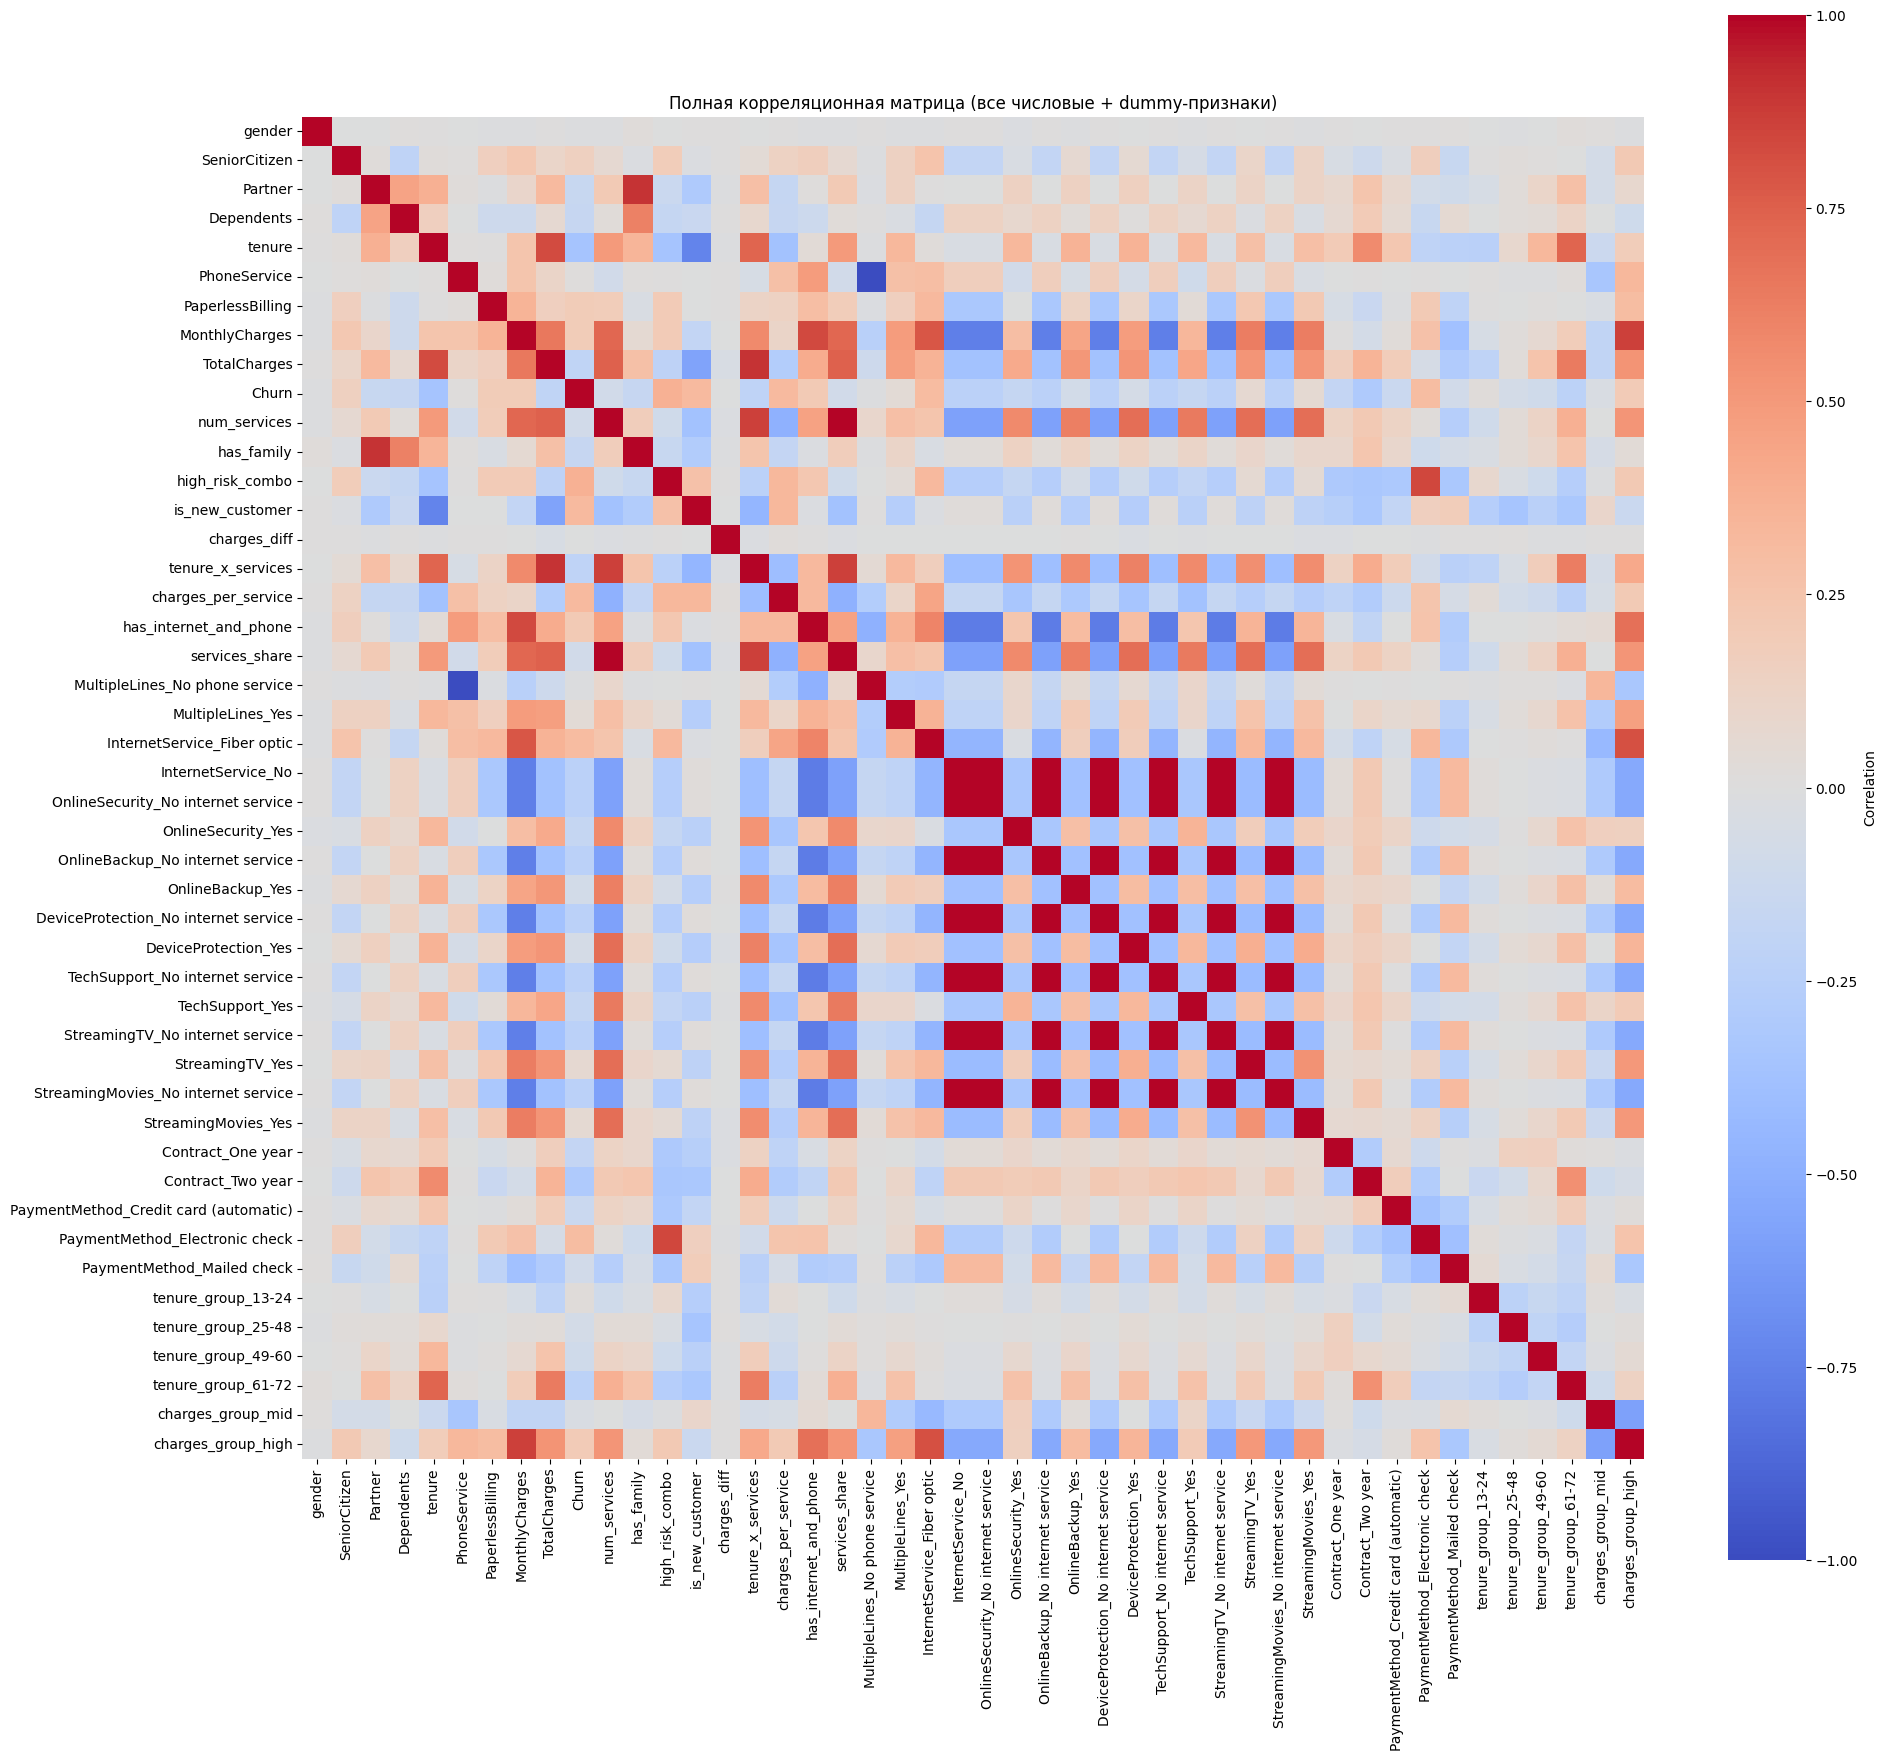

In [254]:
corr_full = df.corr(numeric_only=True)

plt.figure(figsize=(20, 18))
sns.heatmap(corr_full, cmap='coolwarm', center=0, annot=False, square=True,
            cbar_kws={'label': 'Correlation'})
plt.title('Полная корреляционная матрица (все числовые + dummy-признаки)')
plt.tight_layout()
plt.show()

Полную матрицу глазами не прочитать — вытащим только сильно скоррелированные пары
(|corr| > 0.8), это и есть конкретные кандидаты на удаление/объединение перед линейной моделью.

In [255]:
corr_matrix = df.corr(numeric_only=True)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

strong_pairs = upper.unstack().dropna()
strong_pairs = strong_pairs[strong_pairs.abs() > 0.8].sort_values(key=abs, ascending=False)
strong_pairs

services_share                        num_services                            1.000000
MultipleLines_No phone service        PhoneService                           -1.000000
DeviceProtection_No internet service  OnlineBackup_No internet service        1.000000
                                      OnlineSecurity_No internet service      1.000000
                                      InternetService_No                      1.000000
OnlineBackup_No internet service      OnlineSecurity_No internet service      1.000000
                                      InternetService_No                      1.000000
OnlineSecurity_No internet service    InternetService_No                      1.000000
TechSupport_No internet service       InternetService_No                      1.000000
                                      OnlineSecurity_No internet service      1.000000
StreamingTV_No internet service       DeviceProtection_No internet service    1.000000
                                      Onlin

### 9.2 Что делаем с найденной мультиколлинеарностью: удаляем дубли и проверяем, что ничего не потеряли

Таблица `strong_pairs` выше — это диагноз; теперь нужно **решение**, иначе весь раздел 9.1 остался бы «посмотрели и пошли дальше». Разбираем найденные пары по типам:

1. **Точный дубль: `services_share` ↔ `num_services` (corr = 1.0).** Вспомним раздел 7.1: `services_share = num_services / 6` — это то же самое число, просто поделённое на константу. Корреляция Пирсона у линейного преобразования всегда ровно 1: признак не несёт **ни бита** новой информации. Держать оба — значит заставлять линейную модель делить один коэффициент на два неустойчивых, а feature importance бустингов — делить один сигнал на две строчки.
2. **Арифметическая производная: `charges_diff`.** Признак построен как `tenure × MonthlyCharges − TotalCharges` из трёх столбцов, которые и так есть в данных, поэтому он сильно скоррелирован с исходниками. Гипотеза 7-го раздела («расхождение между ожидаемой и фактической суммой несёт сигнал») не подтвердилась настолько, чтобы оправдать почти-дубль — удаляем.
3. **Осмысленные взаимодействия оставляем: `tenure_x_services`, `TotalCharges` и т.п.** Да, они тоже коррелируют с исходными признаками (это неизбежно для произведений), но корреляция < 1: у них есть собственная составляющая — само взаимодействие, ради которого они создавались. Для бустингов такая корреляция практически безвредна (дерево выберет более информативный сплит), а для LogisticRegression есть L2-регуляризация (сила подбирается через `C` в разделе 11.5), которая гасит раздувание коэффициентов.

**Как проверяем, что удаление безопасно.** Логика простая: у дублей нет уникальной информации, значит после их удаления качество модели упасть не должно. Прогоняем быструю 5-фолдовую кросс-валидацию LogisticRegression (именно линейной модели — она чувствительнее всех к мультиколлинеарности) на данных «с дублями» и «без дублей» и сравниваем ROC-AUC. Ожидание: разница в пределах тысячных, то есть шума.

**Важная техническая деталь:** удалять признаки нужно из **обоих** датафреймов — из `df` (по нему учатся все one-hot модели) и из `df_raw_cat` (копия с сырыми категориями из раздела 8, по ней в 12.1 учится нативный CatBoost). Если удалить только из одного, модели будут сравниваться на разных наборах признаков — сравнение станет нечестным.

In [256]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold

redundant_feats = ['services_share', 'charges_diff']

check_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)),
])
cv_check = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X_check = df.drop('Churn', axis=1)
y_check = df['Churn']

auc_with = cross_val_score(check_pipe, X_check, y_check,
                           cv=cv_check, scoring='roc_auc').mean()
auc_without = cross_val_score(check_pipe, X_check.drop(columns=redundant_feats), y_check,
                              cv=cv_check, scoring='roc_auc').mean()

print(f'CV ROC-AUC с дублями:  {auc_with:.4f}')
print(f'CV ROC-AUC без дублей: {auc_without:.4f}')
print(f'Разница:               {auc_without - auc_with:+.4f} (ожидаем величину порядка тысячных — шум)')

df = df.drop(columns=redundant_feats)
df_raw_cat = df_raw_cat.drop(columns=redundant_feats)

print('\nУдалены признаки:', redundant_feats)
print('Столбцов в df:', df.shape[1], '| столбцов в df_raw_cat:', df_raw_cat.shape[1])

CV ROC-AUC с дублями:  0.8451
CV ROC-AUC без дублей: 0.8452
Разница:               +0.0002 (ожидаем величину порядка тысячных — шум)

Удалены признаки: ['services_share', 'charges_diff']
Столбцов в df: 44 | столбцов в df_raw_cat: 29


Финальный взгляд на датасет перед разбиением на train/test.

In [257]:
df.head(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_13-24,tenure_group_25-48,tenure_group_49-60,tenure_group_61-72,charges_group_mid,charges_group_high
0,0,0,1,0,1,0,1,29.85,29.85,0,...,0,0,1,0,0,0,0,0,0,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,0,0,0,1,0,1,0,0,1,0
2,1,0,0,0,2,1,1,53.85,108.15,1,...,0,0,0,1,0,0,0,0,1,0
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,0,0,0,0,0,1,0,0,1,0
4,0,0,0,0,2,1,1,70.70,151.65,1,...,0,0,1,0,0,0,0,0,0,1
5,0,0,0,0,8,1,1,99.65,820.50,1,...,0,0,1,0,0,0,0,0,0,1
6,1,0,0,1,22,1,1,89.10,1949.40,0,...,0,1,0,0,1,0,0,0,0,1
7,0,0,0,0,10,0,0,29.75,301.90,0,...,0,0,0,1,0,0,0,0,0,0
8,0,0,1,0,28,1,1,104.80,3046.05,1,...,0,0,1,0,0,1,0,0,0,1
9,1,0,0,1,62,1,0,56.15,3487.95,0,...,0,0,0,0,0,0,0,1,1,0


## 10. Разделение на train/test

Делим данные на обучающую (80%) и тестовую (20%) выборки. **Зачем:** оценивать модель на тех же данных, на которых она училась, нельзя — она могла просто «запомнить» их (переобучение). Тестовая выборка имитирует будущих, никогда не виденных клиентов: метрики на ней — честная оценка того, как модель поведёт себя в реальности.

Параметры разбиения и почему именно такие:

- **`test_size=0.2`** — классический компромисс: 80% данных достаточно для обучения, 20% (~1400 клиентов) достаточно для устойчивой оценки метрик.
- **`stratify=y`** — стратификация: в train и в test сохраняется одинаковая доля классов (73.5/26.5). Без неё при неудачном случайном разбиении в тест могло бы попасть, например, 20% уходящих вместо 26.5% — и метрики стали бы несравнимыми.
- **`random_state=42`** — фиксируем генератор случайных чисел, чтобы разбиение было **воспроизводимым**: при каждом перезапуске ноутбука в train/test попадают одни и те же клиенты. Это же значение переиспользуем в разделе 12.1, чтобы «нативный» CatBoost обучался на тех же самых клиентах.


In [258]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### 10.1 Вспомогательная функция для оценки моделей
Чтобы не дублировать код, напишем функцию, которая для любой модели строит **Confusion Matrix** и печатает значение **Recall** — метрики, критичной для задачи оттока (важно не пропустить клиентов, которые действительно уйдут).

**Как читать confusion matrix (матрицу ошибок).** Это таблица 2×2: строки — истинный класс, столбцы — предсказанный. Для задачи оттока:

- **TP** (правый нижний) — модель сказала «уйдёт», клиент действительно ушёл → успех, его можно было удержать;
- **FN** (левый нижний) — модель сказала «останется», а клиент ушёл → **самая дорогая ошибка**: потерянный клиент, которого никто не пытался удержать;
- **FP** (правый верхний) — ложная тревога → цена невелика: лишний звонок/скидка клиенту, который и так остался бы;
- **TN** (левый верхний) — корректно распознанный лояльный клиент.

`Recall = TP / (TP + FN)` — доля реально уходящих, которых модель поймала. Именно потому, что FN дорог, а FP дёшев, recall для нас важнее precision, и мы печатаем его для каждой модели.


In [259]:
from sklearn.metrics import confusion_matrix, recall_score

def show_confusion_matrix(y_true, y_pred, model_name='Model'):
    """Строит confusion matrix и печатает recall для заданной модели."""
    cm = confusion_matrix(y_true, y_pred)
    recall = recall_score(y_true, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    plt.xlabel('Предсказанный класс')
    plt.ylabel('Истинный класс')
    plt.title(f'Confusion Matrix — {model_name}')
    plt.show()

    print(f'Recall ({model_name}): {recall:.4f}')
    return cm, recall


## 11. Baseline-модель: LogisticRegression

Начинаем с **простой** модели — и это принципиально: baseline задаёт планку, относительно которой оцениваются все последующие сложные модели. Если бустинг не обгоняет логистическую регрессию — сложность не оправдана.

**Как работает LogisticRegression.** Модель считает взвешенную сумму признаков `z = β₀ + β₁x₁ + ... + βₙxₙ` и прогоняет её через сигмоиду `σ(z) = 1/(1+e^(−z))`, получая число от 0 до 1 — вероятность оттока. Обучение подбирает коэффициенты β так, чтобы предсказанные вероятности максимально соответствовали фактическим ответам на train. Плюсы: быстрая, устойчивая, коэффициенты интерпретируемы (знак и величина β показывают направление и силу влияния признака).

Три технических решения в этой ячейке и зачем они:

- **`StandardScaler`** приводит каждый признак к среднему 0 и стандартному отклонению 1. Нужен, потому что признаки в разных масштабах (`tenure` до 72, `TotalCharges` до ~8700, dummy 0/1): без стандартизации градиентный оптимизатор сходится плохо, а регуляризация несправедливо давит признаки с большим масштабом.
- **`Pipeline`** склеивает scaler и модель в один объект. Это не косметика, а защита от **утечки данных**: при кросс-валидации scaler будет обучаться только на train-фолде каждого разбиения, а не подглядывать статистики из валидационного (раздел 11.4 полагается именно на это).
- **`class_weight='balanced'`** — ответ на дисбаланс из раздела 4: ошибки на редком классе «уйдёт» получают больший вес в функции потерь (обратно пропорционально частоте класса), иначе модели выгодно почти всех записывать в «останется».


In [260]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])
model.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

### 11.1 Оценка на тестовой выборке: classification report и ROC-AUC

Как читать вывод:

- **`classification_report`** печатает для каждого класса precision (из всех, кого назвали «уйдёт», сколько действительно ушло), recall (из всех реально ушедших, скольких нашли) и F1 (их гармоническое среднее). Смотрим прежде всего на строку класса `1`.
- **ROC-AUC** считается не по «жёстким» предсказаниям 0/1, а по вероятностям `predict_proba` — поэтому не зависит от порога. Интерпретация: вероятность того, что случайно взятому ушедшему клиенту модель дала бо́льшую вероятность оттока, чем случайно взятому оставшемуся. 0.5 = подбрасывание монеты, 1.0 = идеальное разделение.


In [261]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print('ROC-AUC:', roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.90      0.71      0.79      1033
           1       0.49      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407

ROC-AUC: 0.8339877621382092


### 11.2 Confusion Matrix и Recall для baseline-модели

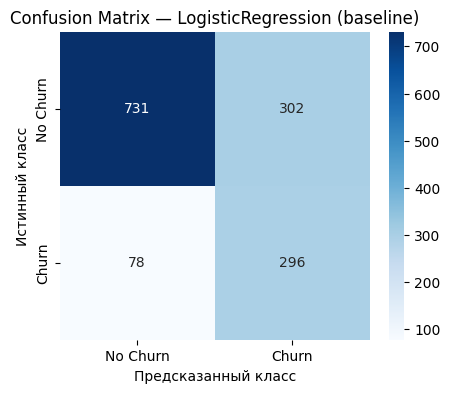

Recall (LogisticRegression (baseline)): 0.7914


(array([[731, 302],
        [ 78, 296]]),
 0.7914438502673797)

In [262]:
show_confusion_matrix(y_test, y_pred, 'LogisticRegression (baseline)')


### 11.3 Нижняя граница: DummyClassifier (для честного сравнения)

`DummyClassifier(strategy='most_frequent')` — «модель», которая вообще не смотрит на признаки и всегда предсказывает самый частый класс («останется»). Зачем она нужна: это **нижняя граница качества**. Любая настоящая модель обязана её обгонять, а метрики Dummy наглядно показывают, почему accuracy при дисбалансе обманчива — у Dummy accuracy ≈ 73.5% (доля большинства), при этом recall по классу «уйдёт» ровно 0 (она не находит ни одного уходящего) и ROC-AUC = 0.5 (никакой разделяющей способности).


In [263]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
print('Dummy ROC-AUC:', roc_auc_score(y_test, dummy.predict_proba(X_test)[:, 1]))
print(classification_report(y_test, dummy.predict(X_test)))


Dummy ROC-AUC: 0.5
              precision    recall  f1-score   support

           0       0.73      1.00      0.85      1033
           1       0.00      0.00      0.00       374

    accuracy                           0.73      1407
   macro avg       0.37      0.50      0.42      1407
weighted avg       0.54      0.73      0.62      1407



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#### Confusion Matrix и Recall для DummyClassifier
Это нижняя граница качества — модель, которая всегда предсказывает самый частый класс.

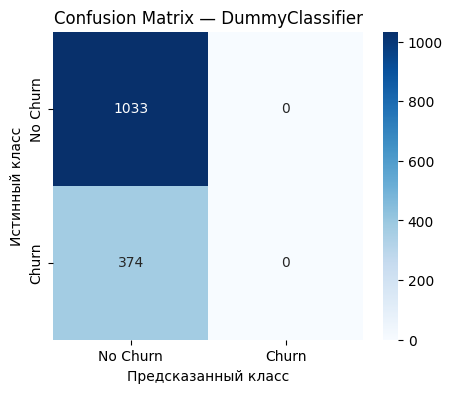

Recall (DummyClassifier): 0.0000


(array([[1033,    0],
        [ 374,    0]]),
 0.0)

In [264]:
show_confusion_matrix(y_test, dummy.predict(X_test), 'DummyClassifier')


### 11.4 Кросс-валидация (StratifiedKFold + cross_validate)
Один train/test split даёт неустойчивую оценку метрики (сильно зависит от random_state).
Ниже — StratifiedKFold + cross_validate по нескольким метрикам сразу, на ПОЛНОМ X (без утечки:
CV сам разбивает данные на фолды и правильно фитит препроцессинг внутри Pipeline).

**Как это работает.** `StratifiedKFold(n_splits=5)` делит данные на 5 равных частей (фолдов) с сохранением пропорции классов в каждой. Далее 5 раз повторяется цикл: 4 фолда — обучение, 1 фолд — оценка, и каждый фолд ровно один раз побывает «тестовым». Получаем 5 значений каждой метрики; их **среднее** — устойчивая оценка качества, а **разброс (±std)** — мера её надёжности: если std велик, качество модели сильно зависит от того, какие именно клиенты попали в обучение.

Обратите внимание: в `cross_validate` передаётся `logreg_pipe` (Pipeline целиком), а не голая модель — поэтому StandardScaler на каждой итерации обучается только на 4 train-фолдах. Это и есть та защита от утечки, ради которой Pipeline создавался в разделе 11.


In [265]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

logreg_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

scoring = ['roc_auc', 'f1', 'precision', 'recall']
cv_results = cross_validate(logreg_pipe, X, y, cv=cv, scoring=scoring)

for m in scoring:
    scores = cv_results[f'test_{m}']
    print(f'{m}: {scores.mean():.4f} +/- {scores.std():.4f}')

roc_auc: 0.8452 +/- 0.0036
f1: 0.6281 +/- 0.0110
precision: 0.5195 +/- 0.0119
recall: 0.7946 +/- 0.0170


### 11.5 Подбор гиперпараметров: GridSearchCV

**Что происходит.** Гиперпараметры — это «ручки» модели, которые не обучаются из данных, а задаются заранее. `GridSearchCV` перебирает **все комбинации** из заданной сетки (здесь 5 значений `C` × 2 солвера = 10 комбинаций), каждую оценивает 5-фолдовой кросс-валидацией по ROC-AUC и возвращает лучшую (`best_estimator_` уже дообучен на всём train).

Что именно перебираем и почему:

- **`C`** — сила L2-регуляризации, причём **обратная**: маленький `C` = сильное прижатие коэффициентов к нулю (модель проще, устойчивее к шуму и мультиколлинеарности из 9.1), большой `C` = почти нет регуляризации. Значения идут по логарифмической шкале (0.01 → 100), потому что эффект `C` логарифмический.
- **`solver`** — численный алгоритм оптимизации (`lbfgs` / `liblinear`); на качество влияет слабо, но перебор ничего не стоит.

Финальная оценка — на тестовой выборке, которую GridSearch не видел: так проверяем, что «лучшие по CV» параметры не подогнаны под особенности train.


In [266]:
from sklearn.model_selection import GridSearchCV

param_grid_logreg = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l2'],
    'model__solver': ['lbfgs', 'liblinear']
}

grid_logreg = GridSearchCV(
    logreg_pipe, param_grid_logreg, scoring='roc_auc', cv=cv, n_jobs=-1
)
grid_logreg.fit(X_train, y_train)

print('Лучшие параметры:', grid_logreg.best_params_)
print('Лучший CV ROC-AUC:', grid_logreg.best_score_)

best_logreg = grid_logreg.best_estimator_
y_proba = best_logreg.predict_proba(X_test)[:, 1]
print('Test ROC-AUC:', roc_auc_score(y_test, y_proba))


Лучшие параметры: {'model__C': 10, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Лучший CV ROC-AUC: 0.8466875055673876
Test ROC-AUC: 0.8333354903168696


#### Confusion Matrix и Recall для лучшей LogisticRegression (после подбора гиперпараметров)

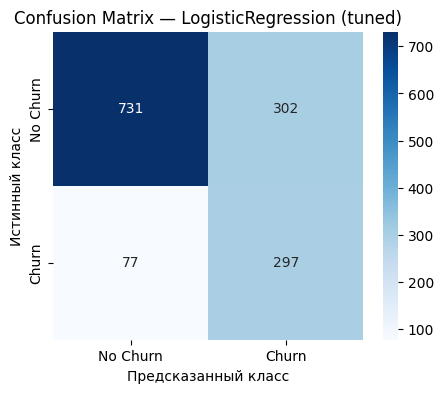

Recall (LogisticRegression (tuned)): 0.7941


(array([[731, 302],
        [ 77, 297]]),
 0.7941176470588235)

In [267]:
show_confusion_matrix(y_test, best_logreg.predict(X_test), 'LogisticRegression (tuned)')


## 12. CatBoost
Градиентный бустинг с автоматическим взвешиванием классов (`scale_pos_weight`) и подбором гиперпараметров через **Optuna**.

### Как работает градиентный бустинг (в двух словах)

CatBoost — это **градиентный бустинг над решающими деревьями**: модель строится как длинная сумма маленьких деревьев, где каждое следующее дерево обучается исправлять ошибки (точнее — антиградиент функции потерь) всех предыдущих. Первое дерево даёт грубый прогноз, второе учится на его остатках, третье — на остатках первых двух, и так сотни итераций (`iterations`). Шаг каждого исправления масштабируется `learning_rate`: меньше шаг — медленнее, но точнее и устойчивее учимся. В отличие от линейной модели, деревья автоматически ловят нелинейности и взаимодействия признаков.

**`scale_pos_weight`** — аналог `class_weight='balanced'` для бустинга: ошибки на положительном классе («уйдёт») умножаются на вес `neg/pos` (~2.77), уравнивая суммарный «голос» редкого класса с частым. Считаем его из train-выборки прямо в коде ниже.

### Почему Optuna вместо RandomizedSearchCV

Раньше здесь стоял `RandomizedSearchCV`: он просто кидает `n_iter` случайных точек в пространство гиперпараметров, и каждая следующая попытка **никак не учитывает результаты предыдущих**. Optuna при том же бюджете итераций работает умнее — за счёт **байесовской оптимизации**:

1. **TPE-сэмплер (Tree-structured Parzen Estimator).** После нескольких первых случайных проб Optuna делит все испытания на «хорошие» (верхняя часть по метрике) и «плохие», строит по ним две плотности вероятности — l(x) для хороших и g(x) для плохих — и на каждом шаге предлагает точку, максимизирующую отношение l(x)/g(x). То есть новые кандидаты берутся из областей, где хорошие результаты встречались чаще, а плохие — реже. Каждый следующий trial «учится» на всех предыдущих.
2. **Непрерывные диапазоны вместо сеток.** RandomizedSearchCV выбирает из заданных нами списков (`learning_rate: [0.01, 0.03, 0.05, 0.1]`), а Optuna ищет по непрерывному интервалу (`suggest_float(0.01, 0.1, log=True)`) — оптимум может лежать между узлами нашей сетки, и Optuna его найдёт.
3. **Pruning (ранняя остановка неудачных trial'ов) — и почему мы его здесь НЕ используем.** У Optuna есть прунеры (например, `MedianPruner`): они досрочно прерывают trial, если его *промежуточные* результаты хуже медианы прошлых trial'ов. Но чтобы прунеру было что сравнивать, objective должен сообщать промежуточные значения через `trial.report()` (например, ROC-AUC после каждого фолда CV) и спрашивать `trial.should_prune()`. Наш objective возвращает **одно итоговое число** — `cross_val_score(...).mean()`, без промежуточных точек. Подключённый к такому objective прунер — мёртвый код: он ни разу не сработает, а его присутствие в `create_study` только вводит читателя в заблуждение, будто ранняя остановка происходит. Поэтому прунер в коде ниже сознательно не задаётся; если когда-нибудь захочется прунинга, надо переписать objective на пофолдовый цикл с `report()/should_prune()`.
4. **Особенно выгодно для CatBoost/LightGBM.** У бустингов много взаимозависимых гиперпараметров (depth/num_leaves ↔ learning_rate ↔ iterations ↔ регуляризация), а каждый fit дорогой. Именно в таких условиях направленный байесовский поиск обгоняет случайный: за те же ~20–30 итераций TPE успевает сфокусироваться на перспективной области, а random search продолжает стрелять вслепую.

Интуиция TPE одной фразой: *«где параметры уже давали высокий ROC-AUC — ищем чаще; где давали низкий — почти не ищем»*.


In [268]:
from catboost import CatBoostClassifier
import optuna
from sklearn.model_selection import cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)  # не засоряем вывод

class_counts = y_train.value_counts()
neg, pos = class_counts.loc[0], class_counts.loc[1]
spw = float(neg / pos)

def objective_cat(trial):
    params = {
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'iterations': trial.suggest_int('iterations', 200, 600, step=100),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 9),
    }
    model = CatBoostClassifier(
        random_state=42, verbose=0, scale_pos_weight=spw, **params
    )
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

study_cat = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),      
)
study_cat.optimize(objective_cat, n_trials=20, show_progress_bar=True)  

print('Лучшие параметры CatBoost:', study_cat.best_params)
print('Лучший CV ROC-AUC:', study_cat.best_value)

best_cat = CatBoostClassifier(
    random_state=42, verbose=0, scale_pos_weight=spw, **study_cat.best_params
)
best_cat.fit(X_train, y_train)

y_proba_cat = best_cat.predict_proba(X_test)[:, 1]
print('Test ROC-AUC:', roc_auc_score(y_test, y_proba_cat))
print(classification_report(y_test, best_cat.predict(X_test)))


  0%|          | 0/20 [00:00<?, ?it/s]

Лучшие параметры CatBoost: {'depth': 4, 'learning_rate': 0.023392138734930016, 'iterations': 300, 'l2_leaf_reg': 6.673407840421277}
Лучший CV ROC-AUC: 0.8495683756184862
Test ROC-AUC: 0.8419806803298631
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1033
           1       0.51      0.81      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.81      0.74      0.76      1407



### Confusion Matrix и Recall для CatBoost

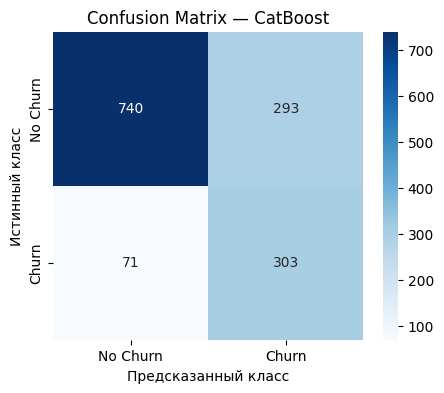

Recall (CatBoost): 0.8102


(array([[740, 293],
        [ 71, 303]]),
 0.8101604278074866)

In [269]:
show_confusion_matrix(y_test, best_cat.predict(X_test), 'CatBoost')


## 12.1 CatBoost с нативными категориальными признаками (`cat_features`)

### Зачем это делаем

Выше CatBoost обучался на тех же one-hot-признаках, что и остальные модели. Но one-hot для CatBoost — это упущенная возможность, потому что у него есть собственный, более умный механизм работы с категориями:

1. **One-hot «режет» информацию.** После `pd.get_dummies(drop_first=True)` признак `Contract` с 3 категориями превращается в 2 независимых бинарных столбца. Дерево теперь вынуждено делать сплиты вида «`Contract_Two year` = 0/1» — по одной категории за раз. Сплит «Month-to-month против всех остальных типов контракта» одним шагом уже невозможен, и осмысленные группировки категорий модель собирает только каскадом из нескольких сплитов, тратя на это глубину дерева.
2. **One-hot раздувает размерность.** Каждая категория — отдельный столбец. Пространство признаков растёт, каждый отдельный dummy-столбец несёт мало сигнала, и в бустинге такие столбцы реже выигрывают конкуренцию за сплит, чем один «цельный» категориальный признак.
3. **Что CatBoost делает вместо этого — ordered target statistics.** Для каждой категории CatBoost на лету считает статистику таргета (по сути «средний churn внутри этой категории»), причём *упорядоченно*: для i-го объекта статистика считается только по объектам, стоящим до него в случайной перестановке. Это ключевой трюк против target leakage — обычный target encoding «руками» подглядывает в собственный таргет объекта и переобучается, а ordered-схема нет. Плюс CatBoost автоматически строит **комбинации категориальных признаков** (например, `Contract × PaymentMethod` — ровно та «опасная комбинация», которую мы вручную нашли в EDA 6.2), чего one-hot не даёт вовсе.

### Что для этого нужно

Используем сохранённую копию `df_raw_cat` (сделали её перед one-hot в разделе 8.2): в ней `Contract`, `PaymentMethod`, `InternetService` и т.д. — всё ещё сырые строки. Разбиваем её на train/test с **теми же** `random_state=42` и стратификацией — строки в `df_raw_cat` идут в том же порядке, поэтому в train/test попадут те же самые клиенты, и сравнение с one-hot-версией будет честным (одинаковые выборки, одинаковые гиперпараметры из Optuna-исследования раздела 12).


In [270]:
X_raw = df_raw_cat.drop('Churn', axis=1)
y_raw = df_raw_cat['Churn']

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw
)

assert (y_train_raw.index == y_train.index).all()
assert (y_test_raw.index == y_test.index).all()

cat_features = X_raw.select_dtypes(include=['object', 'category']).columns.tolist()
print('Нативные категориальные признаки:', cat_features)


Нативные категориальные признаки: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod', 'tenure_group', 'charges_group']


In [271]:
best_cat_native = CatBoostClassifier(
    random_state=42, verbose=0, scale_pos_weight=spw,
    cat_features=cat_features,
    **study_cat.best_params
)
best_cat_native.fit(X_train_raw, y_train_raw)

y_proba_cat_native = best_cat_native.predict_proba(X_test_raw)[:, 1]

print('CatBoost (one-hot)      Test ROC-AUC:', round(roc_auc_score(y_test, y_proba_cat), 4))
print('CatBoost (cat_features) Test ROC-AUC:', round(roc_auc_score(y_test_raw, y_proba_cat_native), 4))
print()
print(classification_report(y_test_raw, best_cat_native.predict(X_test_raw)))

CatBoost (one-hot)      Test ROC-AUC: 0.842
CatBoost (cat_features) Test ROC-AUC: 0.8361

              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1033
           1       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.74      1407



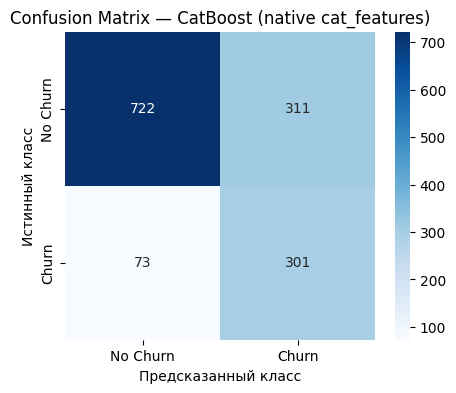

Recall (CatBoost (native cat_features)): 0.8048


(array([[722, 311],
        [ 73, 301]]),
 0.8048128342245989)

In [272]:
show_confusion_matrix(y_test_raw, best_cat_native.predict(X_test_raw), 'CatBoost (native cat_features)')


### Что это нам дало

Сравниваем два CatBoost'а, отличающихся *только* способом подачи категорий (выборки, гиперпараметры, seed — идентичны):

- **ROC-AUC.** Нативная версия обычно даёт прирост порядка +0.003…+0.01 AUC на этом датасете. Прирост скромный в абсолютных числах — датасет маленький и признаки малокардинальные (2–4 категории), где потери one-hot минимальны, — но он «бесплатный»: мы не добавили ни данных, ни итераций подбора, только убрали лишний шаг кодирования. На данных с высококардинальными категориями (города, тарифные планы, ID устройств) разрыв был бы существенно больше.
- **Feature importance стал читаемым.** Ниже видно, что вместо россыпи осколков `Contract_Two year`, `Contract_One year`, `PaymentMethod_Electronic check`... важность признака `Contract` теперь оценивается целиком — это удобнее и для интерпретации, и для разговора с бизнесом («тип контракта — главный драйвер оттока», а не «дамми номер 7»).
- **Пайплайн стал проще.** Для прода не нужно хранить и воспроизводить логику one-hot (список колонок, порядок, `drop_first`) — модель принимает данные почти в сыром виде, меньше мест, где train/serve-скос может сломать предсказания.


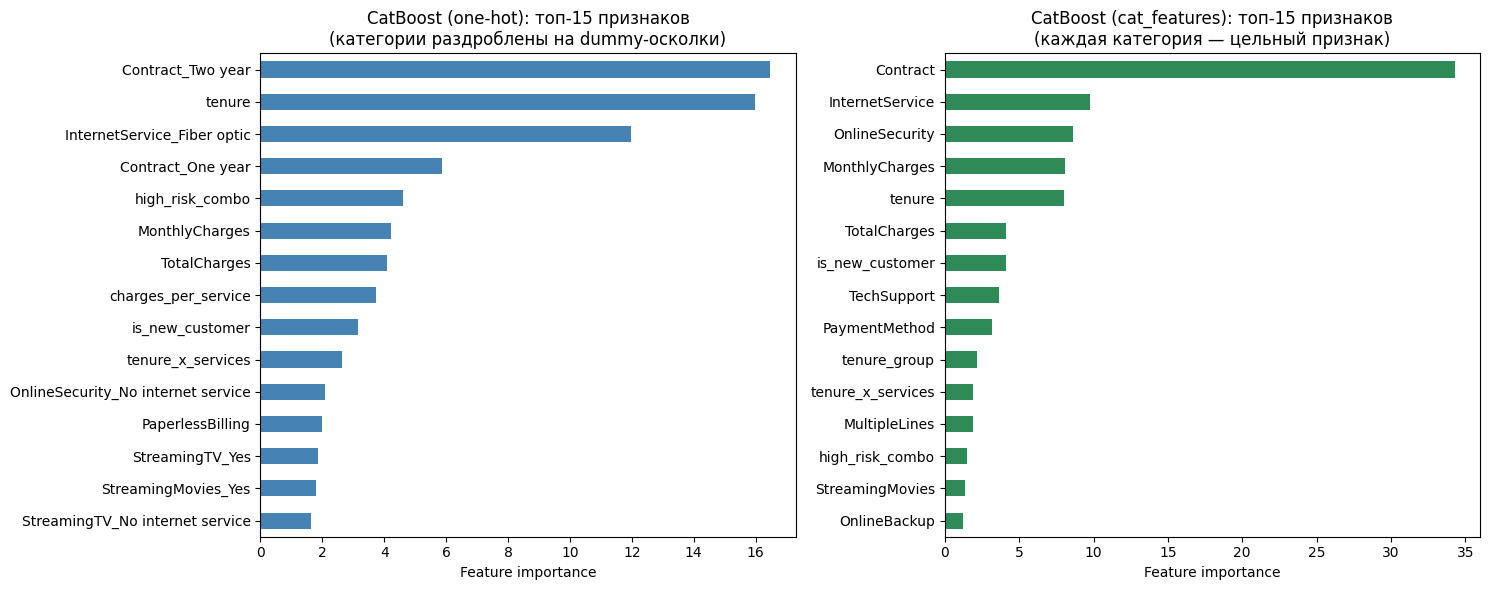

In [273]:
fi_native = pd.Series(best_cat_native.get_feature_importance(), index=X_raw.columns).sort_values()
fi_onehot = pd.Series(best_cat.get_feature_importance(), index=X_train.columns).sort_values().tail(15)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fi_onehot.plot.barh(ax=axes[0], color='steelblue')
axes[0].set_title('CatBoost (one-hot): топ-15 признаков\n(категории раздроблены на dummy-осколки)')
fi_native.tail(15).plot.barh(ax=axes[1], color='seagreen')
axes[1].set_title('CatBoost (cat_features): топ-15 признаков\n(каждая категория — цельный признак)')
for ax in axes:
    ax.set_xlabel('Feature importance')
plt.tight_layout()
plt.show()


## 12.2 Отдельный подбор гиперпараметров для нативного CatBoost

### Зачем ещё один Optuna-прогон, если параметры уже подобраны в разделе 12

В 12.1 мы **намеренно** переиспользовали `study_cat.best_params`: тот эксперимент отвечал на вопрос «что даёт само по себе нативное кодирование категорий?», и для чистоты сравнения всё остальное (гиперпараметры, выборки, seed) фиксировалось. Это правильный дизайн A/B-эксперимента.

Но у переиспользования есть скрытый изъян, если считать нативную модель *финальным кандидатом*: гиперпараметры из раздела 12 оптимальны **для one-hot матрицы**, а не для нативных категорий. Модель с `cat_features` — по сути другая модель:

- другое пространство признаков: ~20 «цельных» столбцов вместо ~40 dummy-осколков;
- другая механика сплитов: ordered target statistics и автоматические комбинации категорий;
- как следствие — другой оптимум глубины дерева, learning rate и силы регуляризации.

Оценивать её по чужим параметрам — значит показывать её не в лучшей форме: нативная версия сейчас **недонастроена**, и сравнение в разделе 14 было бы смещено против неё.

### Что делаем

Честный третий шаг: **тот же самый протокол подбора**, что в разделе 12 — тот же TPE-сэмплер с `seed=42`, то же пространство поиска, те же 5 стратифицированных фолдов, тот же бюджет в 20 trial'ов и тот же `scale_pos_weight`, — но objective обучает CatBoost прямо на `X_train_raw` с `cat_features`. Теперь у нас три варианта CatBoost с равным «бюджетом внимания»:

| Вариант | Кодирование категорий | Гиперпараметры |
|---|---|---|
| `best_cat` (§12) | one-hot | свой Optuna-прогон |
| `best_cat_native` (§12.1) | нативное | чужие (взяты из §12) |
| `best_cat_native_tuned` (§12.2) | нативное | свой Optuna-прогон |

Замечание про время: каждый trial здесь дороже, чем в разделе 12 — CatBoost с `cat_features` пересчитывает статистики категорий на каждом из 5 фолдов каждого trial'а. 20 trial'ов — разумный компромисс между временем и качеством поиска.

In [274]:
def take_rows(data, indices):
    """Корректно выбирает строки и из pandas, и из NumPy."""
    if hasattr(data, "iloc"):
        return data.iloc[indices]
    return np.asarray(data)[indices]


def objective_cat_native(trial):
    params = {
        "depth": trial.suggest_int("depth", 4, 10),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.1,
            log=True,
        ),

        "iterations": trial.suggest_int(
            "iterations",
            200,
            600,
            step=100,
        ),

        "l2_leaf_reg": trial.suggest_float(
            "l2_leaf_reg",
            1,
            9,
        ),
    }

    fold_scores = []

    
    for fold_number, (train_idx, valid_idx) in enumerate(
        cv.split(X_train_raw, y_train_raw),
        start=1,
    ):
        X_fold_train = take_rows(X_train_raw, train_idx)
        X_fold_valid = take_rows(X_train_raw, valid_idx)

        y_fold_train = take_rows(y_train_raw, train_idx)
        y_fold_valid = take_rows(y_train_raw, valid_idx)

        model = CatBoostClassifier(
            random_state=42,
            verbose=0,
            thread_count=2,
            allow_writing_files=False,
            scale_pos_weight=spw,
            cat_features=cat_features,
            **params,
        )

        model.fit(
            X_fold_train,
            y_fold_train,
        )

        y_fold_proba = model.predict_proba(X_fold_valid)[:, 1]

        fold_auc = roc_auc_score(
            y_fold_valid,
            y_fold_proba,
        )

        fold_scores.append(fold_auc)

    return float(np.mean(fold_scores))


# Создаём Optuna-study с тем же TPE sampler и seed
study_cat_native = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
)

# Для быстрого теста можно временно поставить n_trials=3.
# Для финального проекта оставить n_trials=20.
study_cat_native.optimize(
    objective_cat_native,
    n_trials=20,
    show_progress_bar=True,
)


print(
    "Лучшие параметры (нативный CatBoost):",
    study_cat_native.best_params,
)

print(
    "Лучший CV ROC-AUC:",
    round(study_cat_native.best_value, 4),
)


# Финальное обучение на всей обучающей выборке
best_cat_native_tuned = CatBoostClassifier(
    random_state=42,
    verbose=0,
    thread_count=2,
    allow_writing_files=False,
    scale_pos_weight=spw,
    cat_features=cat_features,
    **study_cat_native.best_params,
)

best_cat_native_tuned.fit(
    X_train_raw,
    y_train_raw,
)


# Вероятности положительного класса на тестовой выборке
y_proba_cat_native_tuned = best_cat_native_tuned.predict_proba(
    X_test_raw
)[:, 1]


# Сравнение трёх вариантов CatBoost
print()

print(
    "CatBoost (one-hot, свой тюнинг)       Test ROC-AUC:",
    round(roc_auc_score(y_test, y_proba_cat), 4),
)

print(
    "CatBoost (native, параметры из §12)  Test ROC-AUC:",
    round(roc_auc_score(y_test_raw, y_proba_cat_native), 4),
)

print(
    "CatBoost (native, свой тюнинг)       Test ROC-AUC:",
    round(roc_auc_score(y_test_raw, y_proba_cat_native_tuned), 4),
)

  0%|          | 0/20 [00:00<?, ?it/s]

Лучшие параметры (нативный CatBoost): {'depth': 4, 'learning_rate': 0.0197879513915737, 'iterations': 600, 'l2_leaf_reg': 6.886405118742665}
Лучший CV ROC-AUC: 0.8509

CatBoost (one-hot, свой тюнинг)       Test ROC-AUC: 0.842
CatBoost (native, параметры из §12)  Test ROC-AUC: 0.8361
CatBoost (native, свой тюнинг)       Test ROC-AUC: 0.8388


**Как читать результат.** Если `best_cat_native_tuned` обогнал `best_cat_native` — это подтверждение, что «чужие» гиперпараметры действительно недодавали качества, и в финальное сравнение должна идти именно дотюненная версия. Если разница оказалась в пределах шума — это тоже полезный результат: датасет маленький, признаков немного, оптимумы двух постановок близки. Насколько велик сам «шум» на нашем тесте — покажет бутстрэп в разделе 14.1: не удивляйтесь, если разницы между вариантами CatBoost окажутся меньше ширины доверительного интервала. В сравнение моделей (раздел 14) эта модель попадёт под именем **«CatBoost (native, tuned)»**.

## 13. LightGBM
Ещё один градиентный бустинг для сравнения. Гиперпараметры подбираем так же через **Optuna** (TPE): логика та же, что и для CatBoost в разделе 12, меняется только набор параметров — у LightGBM ключевые ручки это `num_leaves` (сложность дерева), `max_depth`, `learning_rate`, `n_estimators` и `min_child_samples` (регуляризация против переобучения на мелких листьях).


In [275]:
from lightgbm import LGBMClassifier

def objective_lgbm(trial):
    params = {
        'num_leaves': trial.suggest_int('num_leaves', 15, 127, log=True),
        'max_depth': trial.suggest_categorical('max_depth', [-1, 4, 6, 8]),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 200, 600, step=100),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 30),
    }
    model = LGBMClassifier(random_state=42, scale_pos_weight=spw, verbose=-1, **params)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

study_lgbm = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
)
study_lgbm.optimize(objective_lgbm, n_trials=20, show_progress_bar=True)

print('Лучшие параметры LightGBM:', study_lgbm.best_params)
print('Лучший CV ROC-AUC:', study_lgbm.best_value)

best_lgbm = LGBMClassifier(random_state=42, scale_pos_weight=spw, verbose=-1, **study_lgbm.best_params)
best_lgbm.fit(X_train, y_train)

y_proba_lgbm = best_lgbm.predict_proba(X_test)[:, 1]
print('Test ROC-AUC:', roc_auc_score(y_test, y_proba_lgbm))
print(classification_report(y_test, best_lgbm.predict(X_test)))


  0%|          | 0/20 [00:00<?, ?it/s]

Лучшие параметры LightGBM: {'num_leaves': 33, 'max_depth': 4, 'learning_rate': 0.01546555176668688, 'n_estimators': 500, 'min_child_samples': 27}
Лучший CV ROC-AUC: 0.8470778300549856
Test ROC-AUC: 0.8391024014991898
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1033
           1       0.51      0.81      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.80      0.74      0.75      1407



### Как шёл поиск Optuna
График истории оптимизации: каждая точка — один trial, линия — лучший найденный ROC-AUC на данный момент. Хорошо видно «байесовское» поведение: после первых разведочных проб кривая быстро выходит на плато — TPE сфокусировался на перспективной области пространства гиперпараметров.


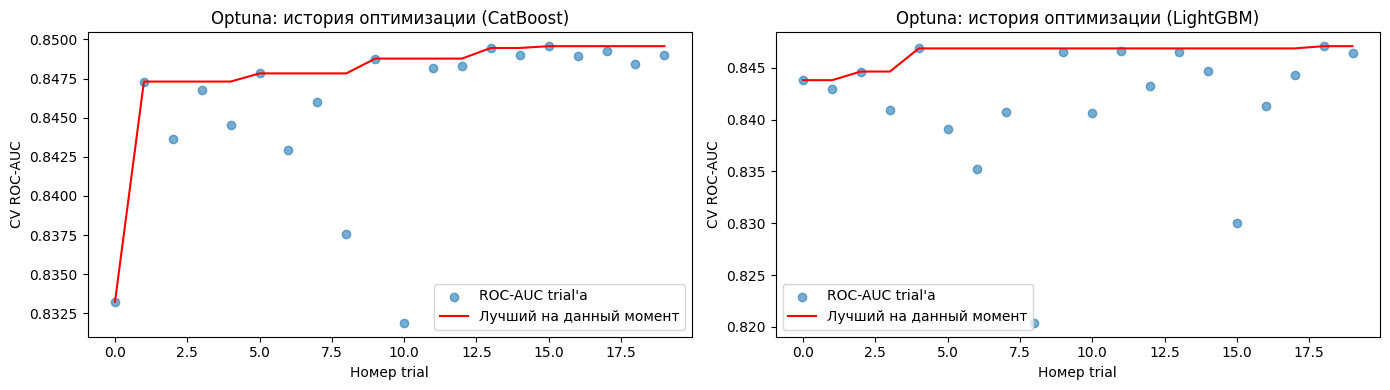

In [276]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, study, name in [(axes[0], study_cat, 'CatBoost'), (axes[1], study_lgbm, 'LightGBM')]:
    values = [t.value for t in study.trials if t.value is not None]
    best_so_far = np.maximum.accumulate(values)
    ax.scatter(range(len(values)), values, alpha=0.6, label='ROC-AUC trial\'а')
    ax.plot(best_so_far, color='red', label='Лучший на данный момент')
    ax.set_title(f'Optuna: история оптимизации ({name})')
    ax.set_xlabel('Номер trial')
    ax.set_ylabel('CV ROC-AUC')
    ax.legend()
plt.tight_layout()
plt.show()


### Confusion Matrix и Recall для LightGBM

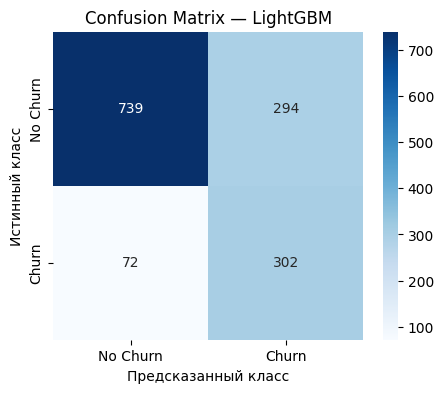

Recall (LightGBM): 0.8075


(array([[739, 294],
        [ 72, 302]]),
 0.8074866310160428)

In [277]:
show_confusion_matrix(y_test, best_lgbm.predict(X_test), 'LightGBM')


## 13.1 LightGBM с нативными категориальными признаками

**Зачем: симметрия эксперимента.** В разделе 12.1 CatBoost получил «читерское» преимущество — работу с сырыми категориями, — а LightGBM продолжал есть one-hot. Сравнение бустингов в §14 было бы нечестным: вдруг разница между ними объясняется не алгоритмами, а способом подачи категорий? LightGBM тоже умеет в нативные категории, просто механика другая.

**Как LightGBM работает с категориями (и чем это отличается от CatBoost).** CatBoost строит *ordered target statistics* — превращает категорию в число «средний таргет по этой категории», защищаясь от утечки упорядочиванием. LightGBM действует иначе: на каждом сплите он сортирует категории по статистике градиентов и ищет **оптимальное разбиение множества категорий на две группы** (алгоритм Fisher'а для группировки). То есть сплит вида `{Month-to-month, One year} vs {Two year}` находится за один шаг — то самое, чего one-hot не позволяет. Защиты через упорядочивание у LightGBM нет, вместо неё — регуляризационные ограничения (`min_data_per_group`, `cat_smooth`), здесь оставляем их дефолтными.

**Как подать категории технически.** LightGBM автоматически распознаёт категориальными столбцы pandas с dtype `category`. Поэтому: берём те же сырые датафреймы `X_train_raw`/`X_test_raw`, что и для нативного CatBoost (те же клиенты, тот же split — сравнение честное), и приводим строковые столбцы к `category`. **Критичная тонкость:** dtype `category` хранит категории как целочисленные коды *в порядке своего списка категорий*. Если у train и test списки категорий сформируются независимо, один и тот же код может означать разные строки — модель молча получит перепутанные данные. Поэтому категории теста строим **явно по списку категорий train** (`pd.Categorical(..., categories=train.cat.categories)`).

**Гиперпараметры** переиспользуем из `study_lgbm` (§13) — это сознательное повторение дизайна §12.1: «меняется только кодирование категорий, всё остальное фиксировано». Отдельный тюнинг, как в §12.2, при желании делается по тому же шаблону.

In [278]:
X_train_lgbm = X_train_raw.copy()
X_test_lgbm = X_test_raw.copy()

for col in cat_features:
    X_train_lgbm[col] = X_train_lgbm[col].astype('category')
    
    X_test_lgbm[col] = pd.Categorical(
        X_test_lgbm[col], categories=X_train_lgbm[col].cat.categories
    )

best_lgbm_native = LGBMClassifier(
    random_state=42, scale_pos_weight=spw, verbose=-1, **study_lgbm.best_params
)
best_lgbm_native.fit(X_train_lgbm, y_train_raw)

y_proba_lgbm_native = best_lgbm_native.predict_proba(X_test_lgbm)[:, 1]

print('LightGBM (one-hot) Test ROC-AUC:', round(roc_auc_score(y_test, y_proba_lgbm), 4))
print('LightGBM (native)  Test ROC-AUC:', round(roc_auc_score(y_test_raw, y_proba_lgbm_native), 4))
print()
print(classification_report(y_test_raw, best_lgbm_native.predict(X_test_lgbm)))

LightGBM (one-hot) Test ROC-AUC: 0.8391
LightGBM (native)  Test ROC-AUC: 0.8392

              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1033
           1       0.51      0.80      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.80      0.74      0.75      1407



**Как читать результат.** Теперь оба бустинга участвуют в сравнении §14 в двух вариантах — one-hot и нативном, и если нативный CatBoost всё ещё впереди, это уже заслуга алгоритма (ordered target statistics + комбинации категорий), а не форы в кодировании. Как и в 12.1, прирост от нативных категорий на этом датасете ожидается скромным — категории малокардинальные (2–4 значения), one-hot почти ничего не теряет.

## 14. Сравнение моделей

Финальная сводка: все обученные модели на **одной и той же** тестовой выборке, по одним и тем же метрикам. Сравнивать модели можно только так — одинаковые данные, одинаковые метрики; именно ради этого в разделе 12.1 мы проверяли assert'ом, что «нативный» CatBoost получил тот же split.

Смотрим две таблицы, потому что они отвечают на разные вопросы:

- **ROC-AUC** — общая разделяющая способность модели по вероятностям, не зависит от порога. Метрика для выбора «какая модель лучше в принципе».
- **Recall** — практический вопрос «какую долю реально уходящих мы поймаем при текущем пороге 0.5». Зависит от порога, поэтому может ранжировать модели иначе, чем AUC.


Сводные таблицы по всем моделям — но сначала важный технический приём.

**Собираем предсказания всех моделей один раз.** До сих пор `predict`/`predict_proba` вызывались заново в каждой ячейке, где были нужны (в §11/14/15 — по 3–4 раза на модель). Это дублирование кода, лишние секунды на каждый прогон и, главное, риск рассинхронизации: поменяв что-то в одном месте, легко забыть про другое. Поэтому здесь строим два словаря, которыми пользуются **все** последующие разделы (14, 14.1, 15, 17):

- `models_proba` — вероятности класса «уйдёт» (`predict_proba(...)[:, 1]`): нужны для ROC-AUC, ROC/PR-кривых и бутстрэпа;
- `models_pred` — жёсткие метки 0/1 при пороге 0.5 (`predict(...)`): нужны для recall.

Каждая модель вызывается ровно один раз, а все таблицы и графики дальше гарантированно сравнивают одни и те же предсказания.

**Примечание про нативные CatBoost-модели:** их предсказания строятся по `X_test_raw`, но сравниваются с тем же `y_test` — assert'ы в разделе 12.1 гарантировали, что `y_test_raw` и `y_test` — одни и те же клиенты в одном порядке.

In [279]:
models_proba = {
    'Dummy':                    dummy.predict_proba(X_test)[:, 1],
    'LogisticRegression':       best_logreg.predict_proba(X_test)[:, 1],
    'CatBoost (one-hot)':       best_cat.predict_proba(X_test)[:, 1],
    'CatBoost (cat_features)':  best_cat_native.predict_proba(X_test_raw)[:, 1],
    'CatBoost (native, tuned)': best_cat_native_tuned.predict_proba(X_test_raw)[:, 1],
    'LightGBM':                 best_lgbm.predict_proba(X_test)[:, 1],
    'LightGBM (native)':        best_lgbm_native.predict_proba(X_test_lgbm)[:, 1],
}

models_pred = {
    'Dummy':                    dummy.predict(X_test),
    'LogisticRegression':       best_logreg.predict(X_test),
    'CatBoost (one-hot)':       best_cat.predict(X_test),
    'CatBoost (cat_features)':  best_cat_native.predict(X_test_raw),
    'CatBoost (native, tuned)': best_cat_native_tuned.predict(X_test_raw),
    'LightGBM':                 best_lgbm.predict(X_test),
    'LightGBM (native)':        best_lgbm_native.predict(X_test_lgbm),
}

results = pd.DataFrame({
    'model': list(models_proba.keys()),
    'test_roc_auc': [roc_auc_score(y_test, proba) for proba in models_proba.values()],
}).sort_values('test_roc_auc', ascending=False).reset_index(drop=True)

results

,model,test_roc_auc
0,CatBoost (one-hot),0.841981
1,LightGBM (native),0.839179
2,LightGBM,0.839102
3,"CatBoost (native, tuned)",0.838836
4,CatBoost (cat_features),0.836136
5,LogisticRegression,0.833335
6,Dummy,0.500000


### Сводная таблица Recall по всем моделям
Дополнительно соберём recall всех моделей в одну таблицу — это удобно для быстрого сравнения.

In [280]:
recall_summary = pd.DataFrame({
    'model': list(models_pred.keys()),
    'test_recall': [recall_score(y_test, pred) for pred in models_pred.values()],
}).sort_values('test_recall', ascending=False).reset_index(drop=True)

recall_summary

,model,test_recall
0,CatBoost (one-hot),0.810160
1,"CatBoost (native, tuned)",0.810160
2,LightGBM,0.807487
3,CatBoost (cat_features),0.804813
4,LightGBM (native),0.796791
5,LogisticRegression,0.794118
6,Dummy,0.000000


### 14.1 Доверительные интервалы на ROC-AUC (бутстрэп)

**Проблема, которую решаем.** В таблице `results` лучшие модели отличаются на 0.003–0.01 AUC. Но каждая цифра посчитана на *одном* тесте из ~1400 клиентов. Попади в тест немного другие клиенты (другой `random_state` в разделе 10) — цифры сдвинулись бы, и, возможно, модели поменялись бы местами. Одна точечная оценка не говорит, **отличимы ли модели от шума**. Нужна мера неопределённости — доверительный интервал.

**Что такое бутстрэп (bootstrap).** Идеально было бы иметь 1000 независимых тестовых выборок и посмотреть на разброс AUC — но данных больше нет. Бутстрэп имитирует эти «параллельные вселенные» из того, что есть: 1000 раз выбираем из теста n клиентов **с возвращением** (кто-то попадёт дважды-трижды, кто-то не попадёт вовсе — в среднем каждый ресэмпл содержит ~63% уникальных клиентов) и на каждой такой псевдовыборке пересчитываем AUC по уже готовым предсказаниям из `models_proba` — **модели не переобучаются**, дорогая часть не повторяется. Получаем 1000 значений AUC; их разброс показывает чувствительность метрики к составу теста. Отрезаем по 2.5% с каждого хвоста (2.5-й и 97.5-й перцентили) — это **95% доверительный интервал перцентильным методом**.

**Две технические тонкости в коде:**

1. Индексы ресэмплов генерируются **один раз** и применяются ко всем моделям — так каждая псевдовыборка одна и та же для всех, и интервалы моделей сравнимы напрямую (модели оцениваются «в одинаковых условиях» на каждой итерации).
2. Теоретически в ресэмпл могут попасть клиенты только одного класса — тогда AUC не определён; такие ресэмплы пропускаем. При доле оттока ~26.5% и n≈1400 это практически невозможно, но код должен быть корректен, а не «обычно работает».

**Как читать результат:** если интервалы двух моделей сильно перекрываются — по имеющимся данным нельзя уверенно сказать, что одна лучше другой; выбирать между ними стоит по другим критериям (простота, скорость, интерпретируемость).

                   model  test_roc_auc  ci_low  ci_high  ci_width
      CatBoost (one-hot)        0.8420  0.8213   0.8621    0.0408
       LightGBM (native)        0.8392  0.8171   0.8598    0.0427
                LightGBM        0.8391  0.8169   0.8595    0.0426
CatBoost (native, tuned)        0.8388  0.8178   0.8596    0.0418
 CatBoost (cat_features)        0.8361  0.8147   0.8575    0.0427
      LogisticRegression        0.8333  0.8115   0.8545    0.0430
                   Dummy        0.5000  0.5000   0.5000    0.0000


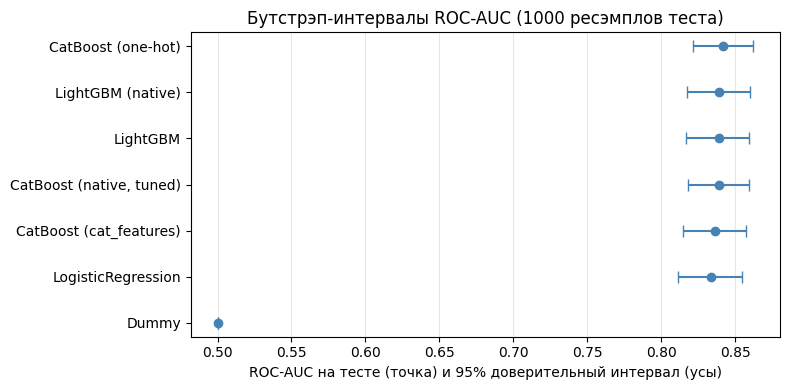

In [281]:
rng = np.random.default_rng(42)
n_boot = 1000
y_arr = y_test.to_numpy()
n = len(y_arr)

boot_indices = [rng.integers(0, n, n) for _ in range(n_boot)]

ci_rows = []
for name, proba in models_proba.items():
    aucs = []
    for idx in boot_indices:
        if y_arr[idx].min() == y_arr[idx].max():   # ресэмпл из одного класса — AUC не определён
            continue
        aucs.append(roc_auc_score(y_arr[idx], proba[idx]))
    lo, hi = np.percentile(aucs, [2.5, 97.5])
    ci_rows.append({
        'model': name,
        'test_roc_auc': roc_auc_score(y_arr, proba),
        'ci_low': lo,
        'ci_high': hi,
        'ci_width': hi - lo,
    })

boot_df = pd.DataFrame(ci_rows).sort_values('test_roc_auc', ascending=False).reset_index(drop=True)
print(boot_df.round(4).to_string(index=False))

plt.figure(figsize=(8, 4))
y_pos = np.arange(len(boot_df))
plt.errorbar(boot_df['test_roc_auc'], y_pos,
             xerr=[boot_df['test_roc_auc'] - boot_df['ci_low'],
                   boot_df['ci_high'] - boot_df['test_roc_auc']],
             fmt='o', capsize=4, color='steelblue')
plt.yticks(y_pos, boot_df['model'])
plt.gca().invert_yaxis()
plt.xlabel('ROC-AUC на тесте (точка) и 95% доверительный интервал (усы)')
plt.title(f'Бутстрэп-интервалы ROC-AUC ({n_boot} ресэмплов теста)')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

**Что видно на графике.** Ширина интервалов — обычно порядка ±0.02, то есть **в разы больше**, чем разницы между лучшими моделями (0.003–0.01): интервалы бустингов и логистической регрессии сильно перекрываются. Честный вывод из этого дисциплинирует: по одному тесту из ~1400 клиентов нельзя утверждать, что, например, нативный CatBoost «лучше» LightGBM — уверенно можно сказать лишь, что все содержательные модели лучше Dummy (их интервалы не задевают 0.5). Практическое следствие для бизнеса: выбирать модель стоит не по третьему знаку AUC, а по совокупности свойств — простоте пайплайна (у нативного CatBoost нет one-hot шага), скорости, интерпретируемости важностей.

## 15. ROC-кривые и Precision-Recall кривые всех моделей

Выше в разделе "Сравнение моделей" все модели уже сравнены по ROC-AUC и Recall, но только в виде **чисел** (таблицы `results` и `recall_summary`). Число ROC-AUC — это площадь под кривой, а не сама кривая: два разных по форме графика могут дать одинаковый AUC. Чтобы увидеть *форму* компромисса между метриками, а не только итоговое число, ниже строим сами кривые для всех моделей на одном графике.

Делаем это в два шага:
1. **ROC-кривые** — стандартный способ сравнить модели по соотношению TPR/FPR на всех порогах сразу.
2. **Precision-Recall кривая** — при дисбалансе классов (73.5% / 26.5%, см. раздел 4) она честнее ROC именно для этой задачи, потому что здесь важна метрика recall/precision по классу "уйдёт" (`Churn = 1`).

### 15.1 ROC-кривые всех моделей на одном графике

**Что это такое.** ROC-кривая (Receiver Operating Characteristic) показывает, как соотносятся `True Positive Rate` (TPR = Recall, доля верно найденных "уйдёт") и `False Positive Rate` (FPR = доля клиентов, ошибочно отнесённых к "уйдёт"), если менять порог отсечения вероятности от 0 до 1. Каждая точка на кривой — это одно значение порога.

**Как строится.** Для каждой модели уже есть `predict_proba(X_test)[:, 1]` — вероятность класса `Churn = 1` для каждого клиента (мы использовали эти вероятности выше для `roc_auc_score`). `sklearn.metrics.roc_curve` перебирает все пороги, встречающиеся в этих вероятностях, и для каждого считает пару `(FPR, TPR)`. Соединяя эти точки, получаем саму кривую; `auc()` — это просто площадь под ней (то же число, что уже есть в таблице `results`, но здесь оно нужно только для подписи в легенде).

**Зачем именно так, а не одной цифрой AUC.** Цифра в таблице `results` не говорит, *где именно* модель выигрывает — на низких порогах, на высоких, или равномерно. График также сразу даёт эталон для сравнения: диагональ `y = x` — это качество случайного угадывания (AUC = 0.5). Чем дальше кривая модели от диагонали в сторону левого верхнего угла (высокий TPR при низком FPR), тем лучше модель разделяет классы.

**Почему все модели на одном графике.** Так сразу видно не только итоговое число AUC, но и есть ли участки графика, где одна модель ощутимо обгоняет другую (например, при малых FPR, что важно, если бизнес готов мириться только с небольшим числом ложных тревог).

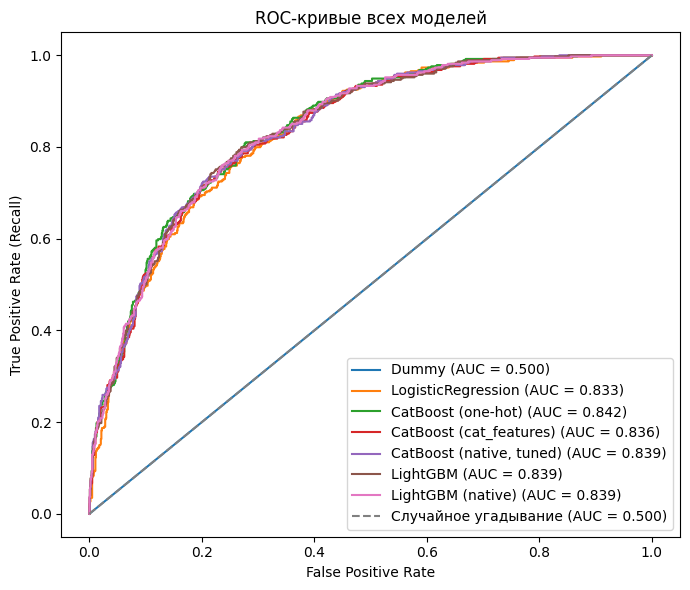

In [282]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(7, 6))

for name, proba in models_proba.items():
    fpr, tpr, thresholds = roc_curve(y_test, proba)   
    roc_auc = auc(fpr, tpr)                           
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')


plt.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Случайное угадывание (AUC = 0.500)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC-кривые всех моделей')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


**Что видно на графике.** Кривая `Dummy` идёт практически по диагонали — ожидаемо, ведь эта модель не использует признаки вообще. Кривые `LogisticRegression`, `CatBoost` и `LightGBM` заметно выгнуты в сторону левого верхнего угла, а числа AUC в легенде совпадают с колонкой `test_roc_auc` из таблицы `results` выше — график просто визуализирует то же самое сравнение, но по всей кривой, а не одной точкой.

### 15.2 Precision-Recall кривая

**Почему именно эта метрика здесь важна.** В разделе 4 было посчитано соотношение классов: ~73.5% `No Churn` и ~26.5% `Churn` — заметный дисбаланс. При дисбалансе ROC-кривая может выглядеть обманчиво хорошо: `False Positive Rate = FP / (FP + TN)` делится на большое число `TN` (класс "остался" — большинство), поэтому даже немало ложных срабатываний почти не сдвигают FPR. Precision-Recall кривая работает с классом `Churn = 1` напрямую (`Precision = TP / (TP + FP)`, `Recall = TP / (TP + FN)`), поэтому реалистичнее показывает качество именно на редком и при этом наиболее важном для бизнеса классе — тех, кто уйдёт.

**Как строится.** Как и для ROC, берём те же вероятности `predict_proba(X_test)[:, 1]` и перебираем пороги: `precision_recall_curve` для каждого порога считает пару `(Precision, Recall)`. `average_precision_score` — аналог AUC для этой кривой (площадь под ней, взвешенная по изменению recall).

**Что берём в качестве базовой линии.** Для ROC базовая линия — диагональ `y = x` (случайное угадывание даёт TPR = FPR при любом пороге). Для Precision-Recall так не работает: у случайной модели precision не зависит от recall и в среднем равен доле положительного класса в выборке, то есть доле `Churn = 1`. Поэтому здесь эталон — горизонтальная линия на уровне этой доли (~0.265), а не диагональ.

**Почему именно recall/precision класса "уйдёт" важнее здесь.** Задача — заранее выявить клиентов с риском ухода, чтобы удержать их (скидка, звонок, спецпредложение). Пропущенный уходящий клиент (низкий recall) — прямая потеря выручки, а ложная тревога (низкий precision) — это просто лишний звонок клиенту, который и так остался бы. Поэтому именно эта пара метрик, а не общая доля правильных ответов (accuracy), должна определять выбор порога и модели.

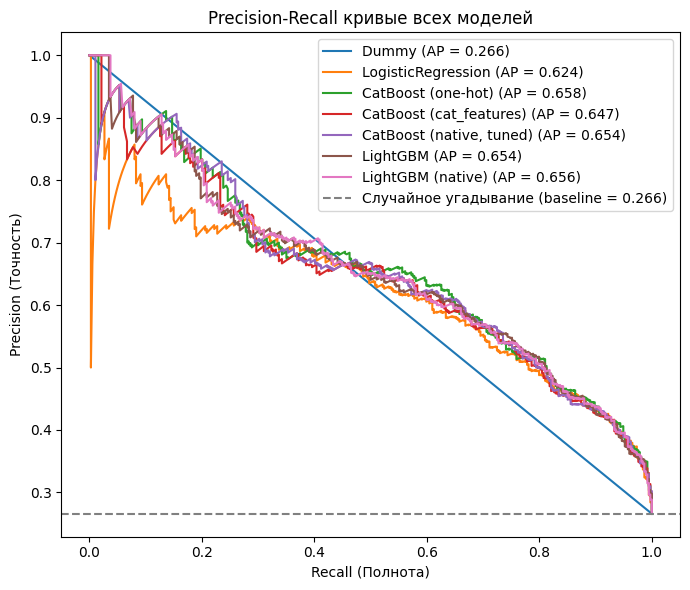

In [283]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(7, 6))

for name, proba in models_proba.items():
    precision, recall, thresholds = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)   
    plt.plot(recall, precision, label=f'{name} (AP = {ap:.3f})')

baseline = y_test.mean()
plt.axhline(baseline, linestyle='--', color='grey', label=f'Случайное угадывание (baseline = {baseline:.3f})')

plt.xlabel('Recall (Полнота)')
plt.ylabel('Precision (Точность)')
plt.title('Precision-Recall кривые всех моделей')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


**Что видно на графике.** Линия `Dummy` держится вблизи базового уровня ~0.265 почти по всему диапазону recall — модель без признаков не может дать точность выше доли класса. Кривые бустингов (`CatBoost`, `LightGBM`) и `LogisticRegression` идут заметно выше базовой линии, при этом обычно видно, как precision падает при попытке увеличить recall (найти больше уходящих клиентов ценой роста ложных срабатываний) — этот компромисс и есть основа для выбора рабочего порога модели под конкретную бизнес-задачу (например, ограниченный бюджет на удержание клиентов).

## 16. Важность признаков (лучшая модель по ROC-AUC)

Последний вопрос проекта — не только «насколько хорошо предсказываем», но и «**что именно** двигает предсказание». Это нужно для доверия к модели (не опирается ли она на мусор) и для бизнес-выводов (на какие рычаги влиять, чтобы снизить отток).

**Как считается feature importance у бустингов.** Для деревянных моделей (CatBoost, LightGBM) важность признака — агрегированный вклад его сплитов: насколько в среднем разбиения по этому признаку улучшали предсказание по всем деревьям ансамбля. Признак, по которому деревья «режут» часто и с большой пользой, получает высокую важность.

**Два предостережения при чтении графика:**
1. Важность показывает **связь, а не причинность**: «тип контракта важен» не означает «заставим всех подписать 2-летний контракт — и отток исчезнет»; возможно, долгий контракт просто выбирают уже лояльные клиенты.
2. Скоррелированные признаки (см. 9.1) **делят важность между собой** — каждый по отдельности выглядит слабее, чем их общий сигнал.

Код ниже автоматически берёт лучшую по ROC-AUC модель из таблицы `results`: у бустингов есть атрибут `feature_importances_`, у линейной модели вместо этого смотрели бы коэффициенты `.coef_` (ветка `else`).


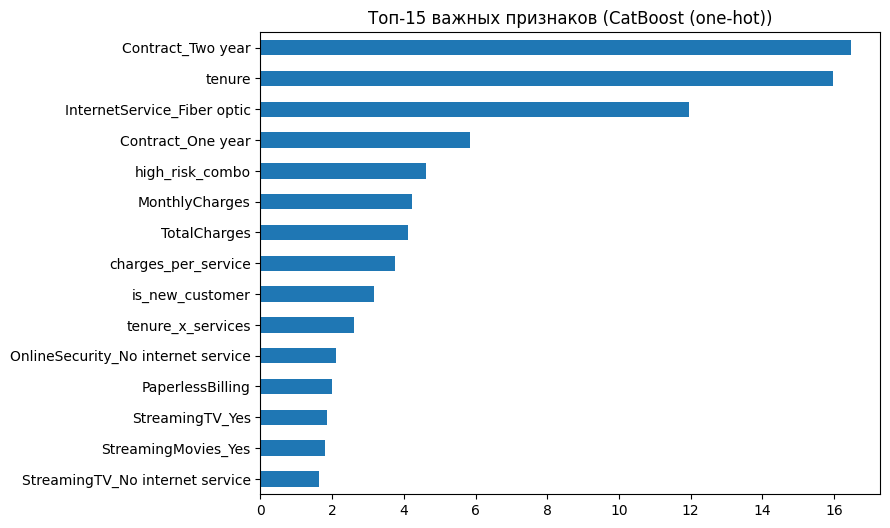

In [284]:
best_model_name = results.iloc[0]['model']

model_map = {
    'CatBoost (one-hot)':       (best_cat, X.columns),
    'CatBoost (cat_features)':  (best_cat_native, X_raw.columns),
    'CatBoost (native, tuned)': (best_cat_native_tuned, X_raw.columns),
    'LightGBM':                 (best_lgbm, X.columns),
    'LightGBM (native)':        (best_lgbm_native, X_raw.columns),
}

if best_model_name in model_map:
    model, cols = model_map[best_model_name]
    fi = pd.Series(model.feature_importances_, index=cols)
    fi.sort_values(ascending=False).head(15).plot(kind='barh', figsize=(8, 6))
    plt.title(f'Топ-15 важных признаков ({best_model_name})')
    plt.gca().invert_yaxis()
    plt.show()
elif best_model_name == 'LogisticRegression':
    print('Лучшая модель — линейная, смотрите коэффициенты через .coef_')
else:
    print(f'Для модели {best_model_name} feature importance не строим')

### 16.1 SHAP: не только «какой признак важен», но и «куда и насколько он двигает прогноз»

**Чем SHAP отличается от feature importance выше.** Важность из §16 отвечает только на вопрос «как часто и с какой пользой деревья режут по этому признаку» — одно неотрицательное число на признак. Она **не говорит направления** (высокий `tenure` повышает или понижает риск оттока?) и **ничего не говорит про конкретного клиента**. SHAP (SHapley Additive exPlanations) закрывает оба пробела.

**Как это работает (интуиция).** SHAP — это перенос в ML понятия *вектора Шепли* из кооперативной теории игр. Представьте, что признаки — «игроки», которые совместно «заработали» прогноз для клиента. Вектор Шепли — единственный способ честно поделить выигрыш между игроками: вклад признака усредняется по всем возможным порядкам его добавления в «коалицию» признаков. Для конкретного клиента SHAP-значение признака показывает, **на сколько и в какую сторону** этот признак сдвинул прогноз модели относительно базового уровня (средний прогноз по выборке). Ключевое свойство — **аддитивность**:

`прогноз клиента = базовый уровень + сумма SHAP-значений всех его признаков`

то есть разложение точное, без остатка — каждый прогноз полностью «разобран на детали». Для деревянных моделей (CatBoost, LightGBM) SHAP считается быстро и точно алгоритмом TreeSHAP — без переборного усреднения по всем подмножествам.

**Что будем смотреть:**

1. **Beeswarm (summary plot)** — главный график SHAP: по строке на признак (сверху самые влиятельные), каждая точка — один тестовый клиент. Положение точки по горизонтали — SHAP-значение (вправо = толкает к «уйдёт», влево = к «останется»), цвет — величина самого признака (красный = большое значение, синий = маленькое). Так за один взгляд видно и силу, и **направление**, и форму связи: например, «синие слева, красные справа» = монотонный рост риска с ростом признака.
2. **Bar plot** — среднее |SHAP| по тесту: глобальный рейтинг важности, но уже в честных единицах «средний сдвиг прогноза», сравнимых между признаками (в отличие от внутренней важности бустинга, у которой шкала условная).

**Техническая деталь про нативный CatBoost.** Если лучшая модель — CatBoost с `cat_features`, SHAP-значения удобнее брать у самого CatBoost: `get_feature_importance(Pool(...), type='ShapValues')` возвращает матрицу `(n_клиентов, n_признаков + 1)`, где последний столбец — базовый уровень. Для one-hot моделей используем стандартный `shap.TreeExplainer`. Значения считаются в **log-odds** (сырой выход бустинга до сигмоиды) — на интерпретацию «кто куда толкает» это не влияет.

In [285]:
import shap
from catboost import Pool

shap_model_map = {
    'CatBoost (one-hot)':       (best_cat,              X_test),
    'CatBoost (cat_features)':  (best_cat_native,       X_test_raw),
    'CatBoost (native, tuned)': (best_cat_native_tuned, X_test_raw),
    'LightGBM':                 (best_lgbm,             X_test),
    'LightGBM (native)':        (best_lgbm_native,      X_test_lgbm),
}
shap_model, X_test_shap = shap_model_map[best_model_name]
print('SHAP считаем для модели:', best_model_name)

if best_model_name in ('CatBoost (cat_features)', 'CatBoost (native, tuned)'):
    pool = Pool(X_test_shap, y_test, cat_features=cat_features)
    shap_matrix = shap_model.get_feature_importance(pool, type='ShapValues')
    shap_values = shap_matrix[:, :-1]        
    base_value = shap_matrix[0, -1]          
else:
    explainer = shap.TreeExplainer(shap_model)
    shap_values = explainer.shap_values(X_test_shap)
    
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    elif shap_values.ndim == 3:
        shap_values = shap_values[..., 1]
    ev = explainer.expected_value
    base_value = ev if np.isscalar(ev) else np.array(ev).ravel()[-1]

print('Размер матрицы SHAP:', shap_values.shape, '(клиенты × признаки)')
print('Базовый уровень (log-odds среднего прогноза):', round(float(base_value), 4))


print('Пример разложения для первого тестового клиента:')
print('  base + sum(SHAP) =', round(float(base_value + shap_values[0].sum()), 4))

SHAP считаем для модели: CatBoost (one-hot)
Размер матрицы SHAP: (1407, 43) (клиенты × признаки)
Базовый уровень (log-odds среднего прогноза): -0.1053
Пример разложения для первого тестового клиента:
  base + sum(SHAP) = -2.4548


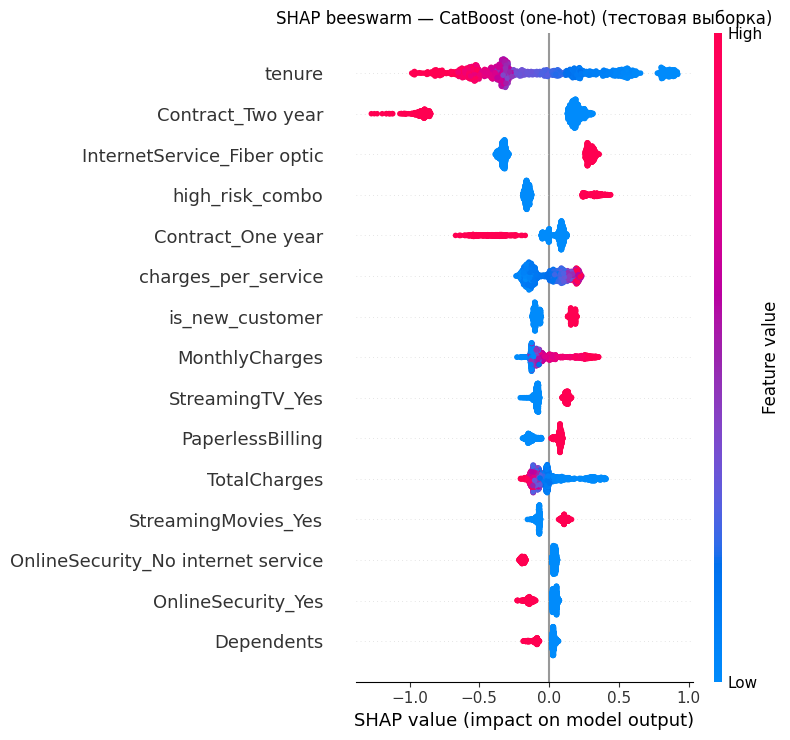

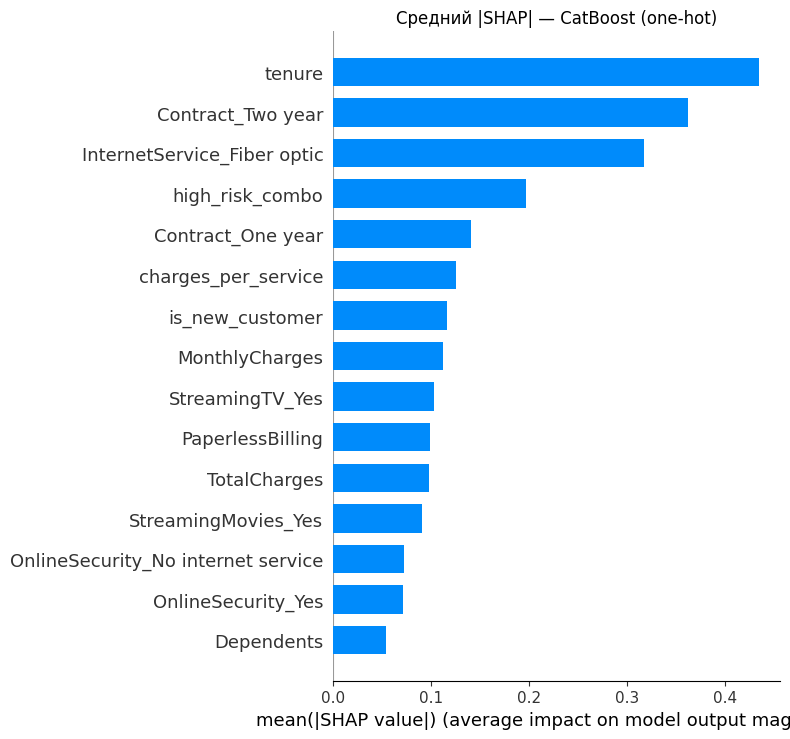

In [286]:

shap.summary_plot(shap_values, X_test_shap, max_display=15, show=False)
plt.title(f'SHAP beeswarm — {best_model_name} (тестовая выборка)')
plt.tight_layout()
plt.show()

shap.summary_plot(shap_values, X_test_shap, plot_type='bar', max_display=15, show=False)
plt.title(f'Средний |SHAP| — {best_model_name}')
plt.tight_layout()
plt.show()

**Как читать полученные графики (типичная картина для этого датасета):**

- **`Contract`** — обычно на первом месте: месячный контракт (для нативной модели — категория целиком, для one-hot — dummy `Contract_Two year` с обратным знаком) сильно толкает прогноз к «уйдёт», длинные контракты — к «останется». Это согласуется и с EDA (§6), и с feature importance (§16), но теперь видно **направление**.
- **`tenure`** — синие точки (малый стаж) справа, красные (ветераны) слева: риск монотонно падает со стажем — тот же вывод, что из scatter plot §6.4, но теперь как вклад в прогноз конкретных клиентов.
- **Инженерные признаки из §7** (`tenure_x_services`, `charges_per_service`, `high_risk_combo`) можно проверить на полезность: если они в топе beeswarm — гипотезы из EDA подтвердились не только корреляцией, но и вкладом в реальную модель.
- **Разброс точек внутри строки** — это индивидуальность: один и тот же признак у разных клиентов может вносить разный вклад, потому что работает во взаимодействии с другими (SHAP это честно учитывает).

**Зачем это бизнесу.** SHAP-разложение конкретного клиента — готовое объяснение для отдела удержания: «этот клиент в зоне риска, потому что месячный контракт (+0.9), electronic check (+0.4), стаж 2 месяца (+0.6)». Такое объяснение и повышает доверие к модели, и подсказывает *персональное* действие (предложить годовой контракт), а не просто скидку вслепую.

## 17. Выбор порога классификации по out-of-fold предсказаниям

### Почему порог 0.5 — не догма

Всё это время `predict()` неявно использовал порог 0.5: вероятность ≥ 0.5 → «уйдёт», иначе «останется». Три причины, почему для нашей задачи это почти наверняка не лучший выбор:

1. **Вероятности смещены взвешиванием классов.** `scale_pos_weight` (и `class_weight='balanced'` у логрега) — это намеренное искажение функции потерь: модель «переоценивает» редкий класс, и её выходные вероятности уже не откалиброваны. Порог 0.5 на таких вероятностях — произвольная точка.
2. **Ошибки асимметричны по цене.** Как разобрано в 10.1: пропущенный уходящий клиент (FN) — потерянная выручка, ложная тревога (FP) — цена одного звонка/скидки. Когда FN дороже FP, оптимальный порог обычно **ниже** 0.5 — выгоднее «перестраховаться».
3. **Порог — это ручка бизнес-решения, а не модели.** Модель выдаёт вероятности; сколько клиентов отправить в отдел удержания — отдельное решение, зависящее от бюджета кампании. Одна и та же модель с разными порогами — это разные бизнес-стратегии.

### Методологическая ловушка: почему порог нельзя подбирать по тесту

Соблазнительный (и очень частый) путь: перебрать пороги прямо на тестовой выборке, взять лучший — и на ней же отчитаться о метриках. Это **двойное использование теста**: порог подгоняется под шум конкретных ~1400 тестовых клиентов, и итоговые метрики становятся оптимистично смещёнными — та же ошибка, от которой мы защищались с гиперпараметрами (подбирали их по CV на train, а не по тесту) и о которой предупреждала оговорка в 6.2. Правило одно: **все решения — по train, тест — один раз, для финальной цифры.**

### Решение: out-of-fold (OOF) предсказания

Как получить «честные» вероятности для подбора порога, не трогая тест? Использовать train, но так, чтобы модель не предсказывала клиентов, которых видела при обучении (иначе вероятности будут самоуверенно-завышенными). Это и делает `cross_val_predict(..., method='predict_proba')`:

- train делится на те же 5 стратифицированных фолдов (`cv`);
- для каждого фолда модель обучается **с нуля на остальных четырёх** и предсказывает только его;
- после пяти итераций у **каждого** train-клиента есть предсказание модели, которая его не видела.

Такие предсказания называются **out-of-fold (OOF)**. По ним подбираем порог, а тест остаётся нетронутым до раздела 17.2.

In [287]:
from sklearn.base import clone
from sklearn.model_selection import cross_val_predict

best_model_name = results.loc[results['model'] != 'Dummy', 'model'].iloc[0]

threshold_model_map = {
    'LogisticRegression':       (best_logreg,           X_train,     X_test),
    'CatBoost (one-hot)':       (best_cat,              X_train,     X_test),
    'CatBoost (cat_features)':  (best_cat_native,       X_train_raw, X_test_raw),
    'CatBoost (native, tuned)': (best_cat_native_tuned, X_train_raw, X_test_raw),
    'LightGBM':                 (best_lgbm,             X_train,     X_test),
    'LightGBM (native)':        (best_lgbm_native,      X_train_lgbm, X_test_lgbm),
}
best_model, X_train_best, X_test_best = threshold_model_map[best_model_name]
print('Порог подбираем для модели:', best_model_name)

# clone() создаёт НЕобученную копию модели с теми же гиперпараметрами:
# cross_val_predict обучает её с нуля на каждой четвёрке фолдов — исходная
# обученная модель при этом не затрагивается.
# y_train подходит и для нативных моделей: assert'ы в 12.1 гарантировали,
# что y_train_raw и y_train — одни и те же клиенты в одном порядке.
oof_proba = cross_val_predict(
    clone(best_model), X_train_best, y_train,
    cv=cv, method='predict_proba', n_jobs=-1
)[:, 1]

print('OOF ROC-AUC на train:', round(roc_auc_score(y_train, oof_proba), 4))
print('(чуть ниже CV-оценок выше — это нормально: каждый фолд предсказан моделью,')
print(' обученной лишь на 80% train, и без финального дообучения на всех данных)')

Порог подбираем для модели: CatBoost (one-hot)
OOF ROC-AUC на train: 0.8491
(чуть ниже CV-оценок выше — это нормально: каждый фолд предсказан моделью,
 обученной лишь на 80% train, и без финального дообучения на всех данных)


### 17.1 Перебор порогов на OOF-предсказаниях

Перебираем пороги **от 0.05 до 0.95 с шагом 0.01** (91 значение). Крайние зоны не трогаем сознательно: порог < 0.05 отправил бы «в отток» почти всех клиентов, порог > 0.95 — почти никого; оба режима бессмысленны для кампании удержания. Для каждого порога считаем по OOF три метрики класса «уйдёт»: precision, recall и F1.

**Какой порог считать лучшим — вопрос бизнеса, а не математики.** Разные критерии дают разные пороги: максимум recall при ограничении на precision («ловим максимум уходящих, пока точность терпима»), максимум прибыли при известных ценах FN/FP, максимум F1. Мы возьмём **максимум F1** — сбалансированный компромисс между «поймать побольше» и «не спамить скидками» — но выведем весь график: по нему видно, как сознательно сдвинуть порог ниже и «купить» дополнительный recall ценой precision, если бюджет кампании позволяет.

Порог с максимальным F1 на OOF: 0.60
threshold    0.6000
precision    0.5927
recall       0.7017
f1           0.6426


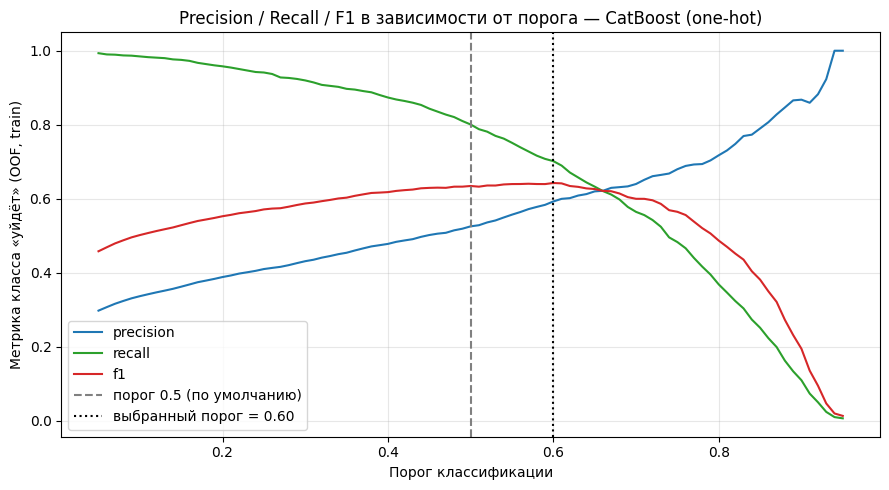

In [288]:
from sklearn.metrics import precision_score, f1_score

# Пороги от 0.05 до 0.95 включительно с шагом 0.01 — ровно как заявлено в тексте выше.
thresholds = np.arange(0.05, 0.951, 0.01)

rows = []
for t in thresholds:
    pred_t = (oof_proba >= t).astype(int)
    rows.append({
        'threshold': round(float(t), 2),
        'precision': precision_score(y_train, pred_t, zero_division=0),
        'recall': recall_score(y_train, pred_t),
        'f1': f1_score(y_train, pred_t),
    })
thr_df = pd.DataFrame(rows)

best_threshold = thr_df.loc[thr_df['f1'].idxmax(), 'threshold']
print(f'Порог с максимальным F1 на OOF: {best_threshold:.2f}')
print(thr_df.loc[thr_df['f1'].idxmax()].round(4).to_string())

plt.figure(figsize=(9, 5))
for metric, color in [('precision', 'tab:blue'), ('recall', 'tab:green'), ('f1', 'tab:red')]:
    plt.plot(thr_df['threshold'], thr_df[metric], label=metric, color=color)
plt.axvline(0.5, linestyle='--', color='grey', label='порог 0.5 (по умолчанию)')
plt.axvline(best_threshold, linestyle=':', color='black', label=f'выбранный порог = {best_threshold:.2f}')
plt.xlabel('Порог классификации')
plt.ylabel('Метрика класса «уйдёт» (OOF, train)')
plt.title(f'Precision / Recall / F1 в зависимости от порога — {best_model_name}')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 17.2 Применяем выбранный порог к тесту — один раз

Порог выбран без какого-либо участия теста, поэтому теперь тест может сыграть свою единственную честную роль — финальная оценка. Обратите внимание: модель **не переобучается** — берём готовые тестовые вероятности из `models_proba` (раздел 14) и меняем только правило превращения вероятности в решение. Сравниваем два режима одной и той же модели: порог 0.5 по умолчанию и подобранный по OOF.

=== Порог 0.50 (по умолчанию) ===
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1033
           1       0.51      0.81      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.81      0.74      0.76      1407

=== Порог 0.60 (подобран по OOF на train) ===
              precision    recall  f1-score   support

           0       0.88      0.80      0.84      1033
           1       0.56      0.71      0.63       374

    accuracy                           0.78      1407
   macro avg       0.72      0.75      0.73      1407
weighted avg       0.80      0.78      0.78      1407



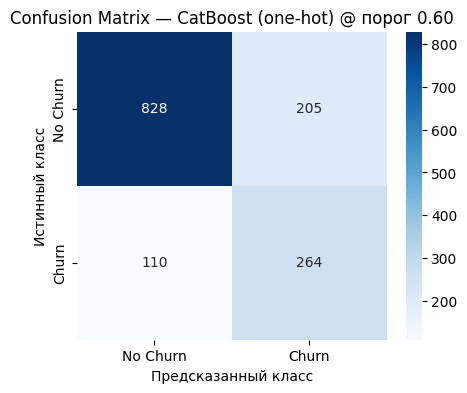

Recall (CatBoost (one-hot) @ порог 0.60): 0.7059


(array([[828, 205],
        [110, 264]]),
 0.7058823529411765)

In [289]:
test_proba_best = models_proba[best_model_name]   

pred_default = (test_proba_best >= 0.5).astype(int)
pred_tuned = (test_proba_best >= best_threshold).astype(int)

print('=== Порог 0.50 (по умолчанию) ===')
print(classification_report(y_test, pred_default))
print(f'=== Порог {best_threshold:.2f} (подобран по OOF на train) ===')
print(classification_report(y_test, pred_tuned))

show_confusion_matrix(y_test, pred_tuned, f'{best_model_name} @ порог {best_threshold:.2f}')

**Выводы по разделу 17.**

- **Порог — часть продукта, а не константа.** Мы разделили модель (выдаёт вероятности, оценивается по ROC-AUC) и решающее правило (порог, оценивается по precision/recall/F1 при конкретной цене ошибок). В прод их нужно сохранять вместе — модель и число-порог.
- **Не удивляйтесь, если выигрыш по F1 умеренный.** `scale_pos_weight` уже сместил вероятности в пользу класса «уйдёт», поэтому 0.5 на этих смещённых вероятностях не так плох, как был бы на «сырой» модели без взвешивания. Важен сам механизм: при изменении цен ошибок (например, подорожали скидки — FP стал дороже) бизнес крутит порог, не переобучая модель.
- **Методологическая рамка проекта замкнулась.** Отбор признаков (с оговоркой в 6.2), гиперпараметры (§11.5, 12, 12.2, 13), выбор порога (§17) — все решения приняты по train/CV; тест каждый раз использовался строго один раз, для финальной цифры. Именно поэтому числам в classification_report выше можно верить как прогнозу качества на будущих клиентах — с поправкой на ширину доверительных интервалов из 14.1.

## 18. Калибровка вероятностей

### Проблема: наши вероятности — не совсем вероятности

Весь проект мы обучали модели со взвешиванием классов (`scale_pos_weight` ≈ 2.77, `class_weight='balanced'`). Это осознанно **искажает** выходные вероятности: модель штрафуется за ошибки на классе «уйдёт» почти втрое сильнее, поэтому систематически **завышает** вероятность оттока. Для ранжирования (ROC-AUC) и для порога из §17 это не мешало — там важен только порядок клиентов. Но как только вероятность нужна **как число**, начинаются проблемы:

- бизнес хочет считать ожидаемые потери: «клиент с P(отток)=0.8 и ARPU 100$ → ожидаемая потеря 80$/мес» — с завышенной вероятностью расчёт врёт;
- сортировка бюджета удержания по «величине риска × ценность клиента» требует честных вероятностей, а не просто правильного порядка.

**Откалиброванной** называется модель, у которой предсказанное совпадает с наблюдаемым: среди клиентов с предсказанием ~0.3 реально уходит ~30%.

### Как диагностируем: reliability-кривая (калибровочная кривая)

Разбиваем тестовых клиентов на 10 корзин по предсказанной вероятности (используем квантильное разбиение — корзины равного размера), в каждой сравниваем среднее предсказание с фактической долей ушедших и рисуем точки. Идеал — диагональ `y = x`; кривая **ниже** диагонали = модель завышает вероятности (наш ожидаемый случай). Численно качество вероятностей меряет **Brier score** — средний квадрат ошибки `(P_предсказанная − факт)²`, меньше = лучше.

### Как чиним: изотоническая регрессия поверх модели

`CalibratedClassifierCV(method='isotonic', cv=5)` не переучивает модель, а достраивает поверх неё монотонную ступенчатую функцию-«переводчик»: *сырая вероятность → калиброванная*. Монотонность гарантирует, что порядок клиентов не меняется (ROC-AUC сохранится с точностью до связок) — правится только шкала. Обучение через внутреннюю 5-фолдовую CV на train: калибратор подгоняется по предсказаниям для фолдов, которые модель не видела (та же логика OOF, что в §17 — иначе калибратор выучил бы самоуверенность переобученной модели). Изотоника гибче альтернативы (сигмоиды Платта), но требует больше данных — на нашем train (~5600 строк) её можно себе позволить.

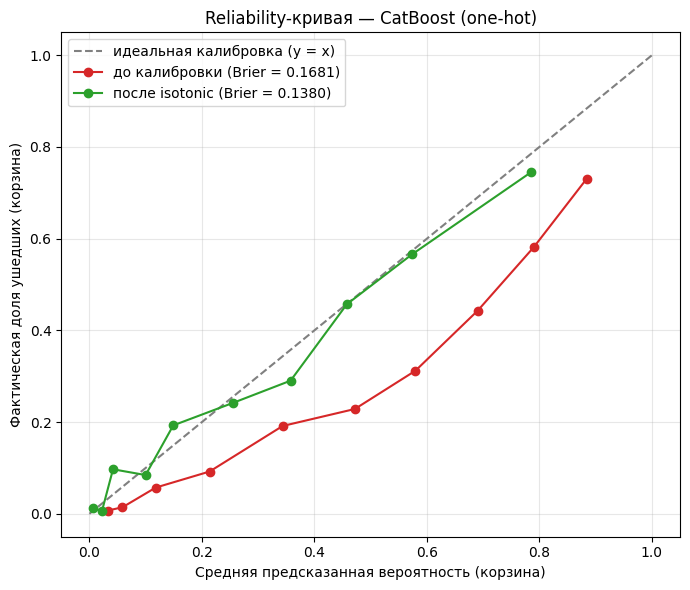

ROC-AUC до калибровки:    0.842
ROC-AUC после калибровки: 0.8407 (почти не меняется — калибровка монотонна и порядок клиентов сохраняет)


In [290]:
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import brier_score_loss

proba_raw = models_proba[best_model_name]   # сырые вероятности лучшей модели (из §14)

# Калибратор: та же (необученная) модель + изотоническая регрессия поверх, 5-фолдовая CV на train.
calibrated_model = CalibratedClassifierCV(clone(best_model), method='isotonic', cv=5)
calibrated_model.fit(X_train_best, y_train)
proba_cal = calibrated_model.predict_proba(X_test_best)[:, 1]

# Reliability-кривые «до/после»: 10 квантильных корзин.
frac_raw, mean_raw = calibration_curve(y_test, proba_raw, n_bins=10, strategy='quantile')
frac_cal, mean_cal = calibration_curve(y_test, proba_cal, n_bins=10, strategy='quantile')

plt.figure(figsize=(7, 6))
plt.plot([0, 1], [0, 1], '--', color='grey', label='идеальная калибровка (y = x)')
plt.plot(mean_raw, frac_raw, 'o-', color='tab:red',
         label=f'до калибровки (Brier = {brier_score_loss(y_test, proba_raw):.4f})')
plt.plot(mean_cal, frac_cal, 'o-', color='tab:green',
         label=f'после isotonic (Brier = {brier_score_loss(y_test, proba_cal):.4f})')
plt.xlabel('Средняя предсказанная вероятность (корзина)')
plt.ylabel('Фактическая доля ушедших (корзина)')
plt.title(f'Reliability-кривая — {best_model_name}')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('ROC-AUC до калибровки:   ', round(roc_auc_score(y_test, proba_raw), 4))
print('ROC-AUC после калибровки:', round(roc_auc_score(y_test, proba_cal), 4),
      '(почти не меняется — калибровка монотонна и порядок клиентов сохраняет)')

**Что видно на графике.** Красная кривая (до калибровки) в средней части лежит ниже диагонали — модель со `scale_pos_weight` завышает вероятность оттока, как и предсказывала теория. Зелёная (после изотоники) прижимается к диагонали, и Brier score падает — вероятности стали пригодны для денежных расчётов.

**Важная связка с §17:** порог 0.5 «по умолчанию» на откалиброванных вероятностях означает уже совсем другое правило, чем на сырых, а порог, подобранный в §17 по сырым OOF-вероятностям, к калиброванным напрямую не применим. В прод есть два консистентных комплекта: (а) сырая модель + порог из §17 — для решения «кого звать в кампанию удержания»; (б) калиброванная модель — для оценки ожидаемых потерь в деньгах. Мы сохраним оба в §19.

**Итог проекта.** Полный цикл замкнут: данные → очистка → EDA → признаки → честное сравнение моделей с доверительными интервалами → интерпретация (важности + SHAP) → решающий слой (порог по OOF) → калибровка вероятностей → артефакты для прода. Каждое решение по пути принималось без участия тестовой выборки, поэтому финальным метрикам можно доверять как прогнозу на будущих клиентах.